In [2]:
# import all necessary libraries
import numpy
import math
import scipy


In [4]:
radius = 7.75
# read data from one of the .dat files in the current directory
if radius == 7.75:
    data = numpy.loadtxt("data/d7p75_avcbs_uniform.dat")
elif radius == 9.0:
    data = numpy.loadtxt("data/d9p00_avcbs_uniform.dat")


In the following cells, we present a method for fitting the data using the following formula: 

The YUMI angular function (from the Nirwala 2025 paper) becomes
$$A_q(\Omega_1, \Omega_2) = A_{\ell \ell_1 \ell_2}(\theta_1, \theta_2, \phi) = \sqrt{\frac{2\ell+1}{4\pi}} \left[(-1)^{\ell_1-\ell_2}\begin{pmatrix}
    \ell_1 & \ell_2 & \ell \\ 0 &0 & 0 
\end{pmatrix} P_{\ell_1}^0 (\cos \theta_1) P_{\ell_2}^0 (\cos \theta_2) + \sum_{m_1 > 0} 2(-1)^{m+\ell_1 - \ell_2}  \begin{pmatrix}
    \ell_1 & \ell_2 & \ell \\ m_1 & -m_1 & 0
\end{pmatrix} P_{\ell_1}^{m_1} (\cos \theta_1) P_{\ell_2}^{m_1} (\cos \theta_2)\cos (m\phi)\right]$$
where the $4\pi$ arises from the normalization constant, and the first term is for when $m = 0$. 

\subsection{Normalization}
    The paper does not use raw Legendre polynomials. Instead, it defines
    $$\Phi_m(\phi) = \frac{1}{\sqrt{2 \pi}} e^{im \phi} \textrm{ and } Y_{\ell m}(\Omega) = P_\ell^m(\theta) \Phi_m(\phi).$$
    Additionally, it uses the normalization
    $$P_\ell^m(\theta) = (-1)^m \left[\frac{2 \ell + 1}{2} \frac{(\ell - m)!}{(\ell+m)!}\right]^{1/2} P_\ell^m (\cos \theta).$$

\subsection{Fitting procedure}

We use only even $\ell_1$ and $\ell_2$ terms. The actual fitting procedure is as follows:

1. We may only have $L$ that satisfy $|\ell_1 - \ell_2 | \leq L \leq \ell_1 + \ell_2$. 
2. Compute each angular basis function at each geometry (that we have actual values for). Create the design matrix $X$ and let $V$ be the target vector (the actual data). The model is $V \qpprox X c(R)$, where $c(R) = \begin{pmatrix} V_{q1}(R) \\ V_{q2}(R) \vdots \end{pmatrix}$. 
3. We now have a least-squares problem which we can solve with numpy. (In later versions, we can also give weight to points but we will not do so for now --- all points have equal weights).

In [5]:
max_l1 = 24
max_l2 = 6
terms = 158

from functools import lru_cache


def _phase(power):
    return -1.0 if power % 2 else 1.0


@lru_cache(maxsize=None)
def wigner_3j(j1, j2, j3, m1, m2, m3):
    """Compute Wigner 3j symbols for integer quantum numbers."""
    if m1 + m2 + m3 != 0:
        return 0.0
    if abs(m1) > j1 or abs(m2) > j2 or abs(m3) > j3:
        return 0.0
    if j3 < abs(j1 - j2) or j3 > j1 + j2:
        return 0.0

    delta = (
        math.factorial(j1 + j2 - j3)
        * math.factorial(j1 - j2 + j3)
        * math.factorial(-j1 + j2 + j3)
        / math.factorial(j1 + j2 + j3 + 1)
    )
    norm = math.sqrt(
        delta
        * math.factorial(j1 + m1)
        * math.factorial(j1 - m1)
        * math.factorial(j2 + m2)
        * math.factorial(j2 - m2)
        * math.factorial(j3 + m3)
        * math.factorial(j3 - m3)
    )

    z_min = max(0, j2 - j3 - m1, j1 + m2 - j3)
    z_max = min(j1 + j2 - j3, j1 - m1, j2 + m2)

    total = 0.0
    for z in range(z_min, z_max + 1):
        denom = (
            math.factorial(z)
            * math.factorial(j1 + j2 - j3 - z)
            * math.factorial(j1 - m1 - z)
            * math.factorial(j2 + m2 - z)
            * math.factorial(j3 - j2 + m1 + z)
            * math.factorial(j3 - j1 - m2 + z)
        )
        total += _phase(z) / denom

    return _phase(j1 - j2 - m3) * norm * total


def normalized_associated_legendre(l, m, x):
    # scipy.special.lpmv includes the Condon-Shortley phase used by the paper's normalization.
    normalization = math.sqrt((2 * l + 1) / 2 * math.factorial(l - m) / math.factorial(l + m))
    return normalization * scipy.special.lpmv(m, l, x)


def angular_basis(L, l1, l2, theta1, theta2, phi):
    x1 = numpy.cos(theta1)
    x2 = numpy.cos(theta2)

    value = (
        _phase(l1 - l2)
        * wigner_3j(l1, l2, L, 0, 0, 0)
        * normalized_associated_legendre(l1, 0, x1)
        * normalized_associated_legendre(l2, 0, x2)
    )

    for m in range(1, min(l1, l2) + 1):
        value += (
            2
            * _phase(m + l1 - l2)
            * wigner_3j(l1, l2, L, m, -m, 0)
            * normalized_associated_legendre(l1, m, x1)
            * normalized_associated_legendre(l2, m, x2)
            * numpy.cos(m * phi)
        )

    return math.sqrt((2 * L + 1) / (4 * math.pi)) * value


def generate_all_terms(max_l1, max_l2):
    valid_terms = []
    for l1 in range(0, max_l1 + 1, 2):
        for l2 in range(0, max_l2 + 1, 2):
            for L in range(abs(l1 - l2), l1 + l2 + 1):
                valid_terms.append((L, l1, l2))

    valid_terms.sort(key=lambda term: (sum(term), term[0], term[1], term[2]))
    return valid_terms


def generate_terms(max_l1, max_l2, terms=None):
    valid_terms = generate_all_terms(max_l1, max_l2)
    if terms is None:
        return valid_terms
    if terms > len(valid_terms):
        raise ValueError(f"Requested {terms} terms, but only {len(valid_terms)} valid terms exist.")
    return valid_terms[:terms]


def design_matrix_for(data_subset, basis_terms):
    subset_theta1 = numpy.deg2rad(data_subset[:, 1])
    subset_theta2 = numpy.deg2rad(data_subset[:, 2])
    subset_phi = numpy.deg2rad(data_subset[:, 3])

    return numpy.column_stack([
        angular_basis(L, l1, l2, subset_theta1, subset_theta2, subset_phi)
        for L, l1, l2 in basis_terms
    ])


def relative_rmse(residuals, targets):
    residuals = numpy.asarray(residuals, dtype=float)
    targets = numpy.asarray(targets, dtype=float)
    target_rms = float(numpy.sqrt(numpy.mean(targets**2)))
    if target_rms == 0:
        return numpy.nan
    return float(numpy.sqrt(numpy.mean(residuals**2)) / target_rms)


def fit_basis(data_subset, basis_terms):
    X_fit = design_matrix_for(data_subset, basis_terms)
    y_fit = data_subset[:, 4]
    coefficients_fit, residual_sum_fit, rank_fit, singular_values_fit = scipy.linalg.lstsq(X_fit, y_fit)
    fitted_values = X_fit @ coefficients_fit
    residuals = y_fit - fitted_values

    return {
        "basis_terms": basis_terms,
        "X": X_fit,
        "V": y_fit,
        "coefficients": coefficients_fit,
        "residual_sum": residual_sum_fit,
        "rank": rank_fit,
        "singular_values": singular_values_fit,
        "fit_values": fitted_values,
        "fit_residuals": residuals,
        "sse": float(numpy.sum(residuals**2)),
        "rmse": float(numpy.sqrt(numpy.mean(residuals**2))),
        "relative_rmse": relative_rmse(residuals, y_fit),
        "max_abs_error": float(numpy.max(numpy.abs(residuals))),
    }


def fit_naive(data_subset, max_l1, max_l2, terms):
    basis_terms = generate_terms(max_l1, max_l2, terms)
    return fit_basis(data_subset, basis_terms)


def print_fit_summary(fit_result, radius=None):
    if radius is not None:
        print(f"Radius: {radius}")
    print(f"Geometries: {len(fit_result['V'])}")
    print(f"Terms used: {len(fit_result['basis_terms'])}")
    print(f"Design matrix shape: {fit_result['X'].shape}")
    print(f"Rank: {fit_result['rank']}")
    print(f"SSE: {fit_result['sse']:.8g}")
    print(f"RMSE: {fit_result['rmse']:.8g}")
    print(f"Relative RMSE: {fit_result['relative_rmse']:.8g}")
    print(f"Max abs error: {fit_result['max_abs_error']:.8g}")


def create_train_test_split(data_subset, train_fraction=0.80, random_seed=202605702):
    rng = numpy.random.default_rng(random_seed)
    shuffled_indices = rng.permutation(len(data_subset))
    train_count = int(train_fraction * len(data_subset))
    training_indices = shuffled_indices[:train_count]
    testing_indices = shuffled_indices[train_count:]

    return data_subset[training_indices], data_subset[testing_indices], training_indices, testing_indices


def fit_and_score(train_subset, test_subset, basis_terms):
    train_fit = fit_basis(train_subset, basis_terms)
    X_test = design_matrix_for(test_subset, basis_terms)
    y_test = test_subset[:, 4]
    test_residuals = y_test - X_test @ train_fit["coefficients"]

    return {
        "test_rmse": float(numpy.sqrt(numpy.mean(test_residuals**2))),
        "test_relative_rmse": relative_rmse(test_residuals, y_test),
        "train_rmse": train_fit["rmse"],
        "train_relative_rmse": train_fit["relative_rmse"],
        "term_count": len(basis_terms),
        "rank": int(train_fit["rank"]),
        "basis_terms": basis_terms,
        "coefficients": train_fit["coefficients"],
        "test_residuals": test_residuals,
    }


def run_basis_cutoff_sweep(train_subset, test_subset, max_l1_grid, max_l2_grid, terms_cap=None):
    test_rmse_grid = numpy.full((len(max_l2_grid), len(max_l1_grid)), numpy.nan)
    train_rmse_grid = numpy.full_like(test_rmse_grid, numpy.nan)
    test_relative_rmse_grid = numpy.full_like(test_rmse_grid, numpy.nan)
    train_relative_rmse_grid = numpy.full_like(test_rmse_grid, numpy.nan)
    term_count_grid = numpy.zeros_like(test_rmse_grid, dtype=int)
    rank_grid = numpy.zeros_like(test_rmse_grid, dtype=int)
    split_fit_results = {}

    for l2_index, sweep_max_l2 in enumerate(max_l2_grid):
        for l1_index, sweep_max_l1 in enumerate(max_l1_grid):
            basis_terms = generate_all_terms(sweep_max_l1, sweep_max_l2)
            if terms_cap is not None:
                basis_terms = basis_terms[:terms_cap]

            result = fit_and_score(train_subset, test_subset, basis_terms)
            test_rmse_grid[l2_index, l1_index] = result["test_rmse"]
            train_rmse_grid[l2_index, l1_index] = result["train_rmse"]
            test_relative_rmse_grid[l2_index, l1_index] = result["test_relative_rmse"]
            train_relative_rmse_grid[l2_index, l1_index] = result["train_relative_rmse"]
            term_count_grid[l2_index, l1_index] = result["term_count"]
            rank_grid[l2_index, l1_index] = result["rank"]
            split_fit_results[(sweep_max_l1, sweep_max_l2)] = result

    best_l2_index, best_l1_index = numpy.unravel_index(numpy.nanargmin(test_rmse_grid), test_rmse_grid.shape)
    best_max_l1 = max_l1_grid[best_l1_index]
    best_max_l2 = max_l2_grid[best_l2_index]
    best_result = split_fit_results[(best_max_l1, best_max_l2)]

    return {
        "max_l1_grid": max_l1_grid,
        "max_l2_grid": max_l2_grid,
        "terms_cap": terms_cap,
        "test_rmse_grid": test_rmse_grid,
        "train_rmse_grid": train_rmse_grid,
        "test_relative_rmse_grid": test_relative_rmse_grid,
        "train_relative_rmse_grid": train_relative_rmse_grid,
        "term_count_grid": term_count_grid,
        "rank_grid": rank_grid,
        "split_fit_results": split_fit_results,
        "color_min": float(numpy.nanmin(test_rmse_grid)),
        "color_max": 10 * float(numpy.nanmin(test_rmse_grid)),
        "best_l2_index": best_l2_index,
        "best_l1_index": best_l1_index,
        "best_max_l1": best_max_l1,
        "best_max_l2": best_max_l2,
        "best_result": best_result,
    }


def plot_sweep_rmse_heatmap(sweep_result, title=None):
    import matplotlib.pyplot as plt

    max_l1_grid = sweep_result["max_l1_grid"]
    max_l2_grid = sweep_result["max_l2_grid"]
    test_rmse_grid = sweep_result["test_rmse_grid"]

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    heatmap = ax.imshow(
        test_rmse_grid,
        origin="lower",
        aspect="auto",
        cmap="viridis_r",
        vmin=sweep_result["color_min"],
        vmax=sweep_result["color_max"],
        extent=[min(max_l1_grid) - 1, max(max_l1_grid) + 1, min(max_l2_grid) - 1, max(max_l2_grid) + 1],
    )

    if title is None:
        if sweep_result["terms_cap"] is None:
            title = "80/20 held-out RMSE by basis cutoff"
        else:
            title = f"80/20 held-out RMSE by basis cutoff, capped at {sweep_result['terms_cap']} terms"

    ax.set_title(title)
    ax.set_xlabel("max l1")
    ax.set_ylabel("max l2")
    ax.set_xticks(max_l1_grid)
    ax.set_yticks(max_l2_grid)
    fig.colorbar(heatmap, ax=ax, label="Testing RMSE", extend="max")

    for l2_index, sweep_max_l2 in enumerate(max_l2_grid):
        for l1_index, sweep_max_l1 in enumerate(max_l1_grid):
            ax.text(
                sweep_max_l1,
                sweep_max_l2,
                f"{test_rmse_grid[l2_index, l1_index]:.3g}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
            )

    return fig, ax


def print_sweep_best(sweep_result, label=""):
    prefix = f"{label} " if label else ""
    best_result = sweep_result["best_result"]
    print(f"Best {prefix}testing RMSE: {best_result['test_rmse']:.8g}")
    print(f"Best {prefix}testing relative RMSE: {best_result['test_relative_rmse']:.8g}")
    print(f"Best {prefix}training relative RMSE: {best_result['train_relative_rmse']:.8g}")
    print(f"Best {prefix}max_l1: {sweep_result['best_max_l1']}")
    print(f"Best {prefix}max_l2: {sweep_result['best_max_l2']}")
    print(f"Terms in best {prefix}fit: {best_result['term_count']}")
    print(f"Training rank in best {prefix}fit: {best_result['rank']}")


naive_fit = fit_naive(data, max_l1, max_l2, terms)

# Keep these names available for the exploratory cells below.
selected_terms = naive_fit["basis_terms"]
X = naive_fit["X"]
V = naive_fit["V"]
coefficients = naive_fit["coefficients"]
residual_sum = naive_fit["residual_sum"]
rank = naive_fit["rank"]
singular_values = naive_fit["singular_values"]
fit_values = naive_fit["fit_values"]
fit_residuals = naive_fit["fit_residuals"]
sse = naive_fit["sse"]
rmse = naive_fit["rmse"]
relative_rmse_value = naive_fit["relative_rmse"]
max_abs_error = naive_fit["max_abs_error"]

print_fit_summary(naive_fit, radius=radius)


Radius: 7.75
Geometries: 500
Terms used: 158
Design matrix shape: (500, 158)
Rank: 105
SSE: 0.040902502
RMSE: 0.0090446119
Relative RMSE: 0.00015879952
Max abs error: 0.047832087


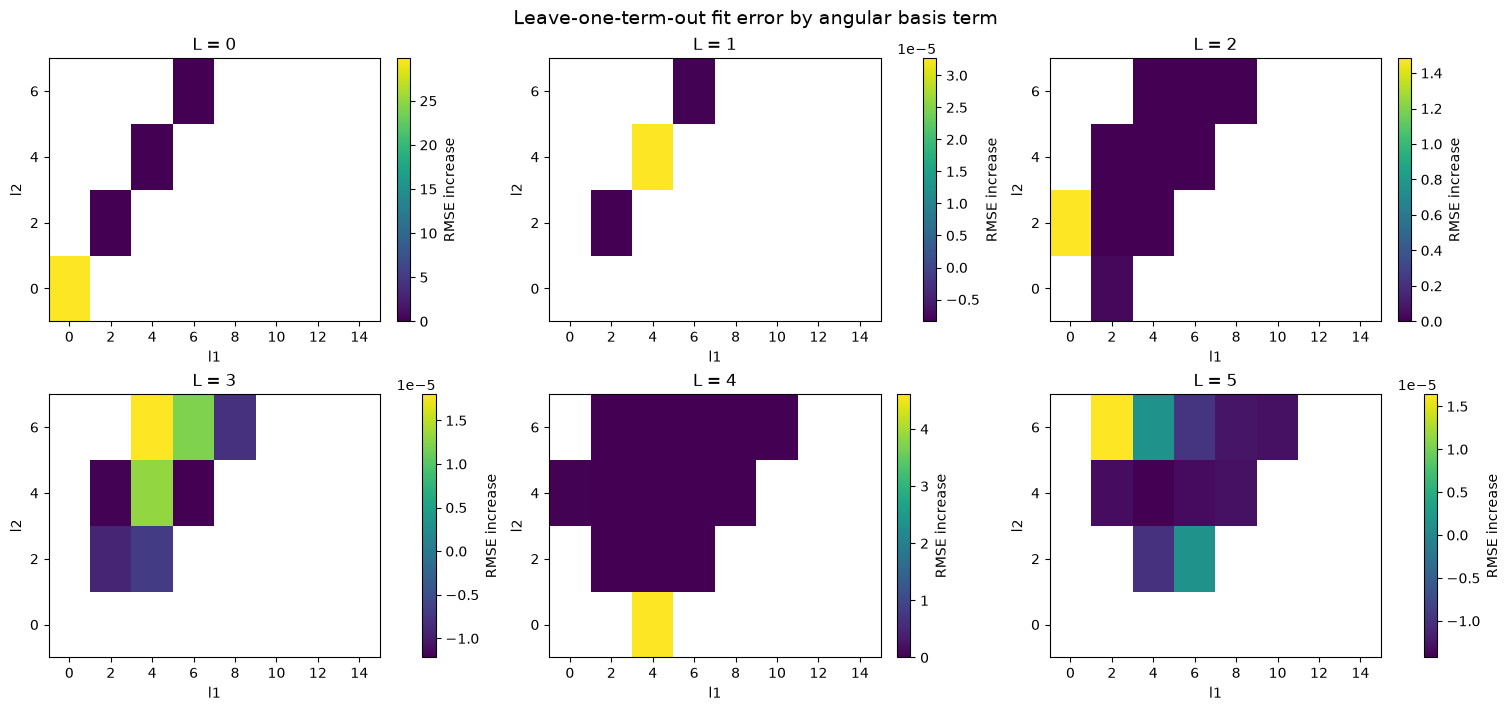

In [6]:
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib-cache"))

import matplotlib.pyplot as plt

# For each displayed L, a heatmap cell shows how much the RMSE increases
# when the corresponding (L, l1, l2) basis term is removed from the fit.
l_values_to_plot = sorted({L for L, _, _ in selected_terms})[:6]
l1_values = sorted({l1 for _, l1, _ in selected_terms})
l2_values = sorted({l2 for _, _, l2 in selected_terms})
term_to_column = {term: column for column, term in enumerate(selected_terms)}


def rmse_without_column(column):
    X_without_term = numpy.delete(X, column, axis=1)
    coefficients_without_term, *_ = scipy.linalg.lstsq(X_without_term, V)
    residuals_without_term = V - X_without_term @ coefficients_without_term
    return float(numpy.sqrt(numpy.mean(residuals_without_term**2)))


fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
axes = axes.ravel()

for ax, L_value in zip(axes, l_values_to_plot):
    rmse_delta_grid = numpy.full((len(l2_values), len(l1_values)), numpy.nan)

    for l2_index, l2 in enumerate(l2_values):
        for l1_index, l1 in enumerate(l1_values):
            term = (L_value, l1, l2)
            if term in term_to_column:
                rmse_delta_grid[l2_index, l1_index] = rmse_without_column(term_to_column[term]) - rmse

    heatmap = ax.imshow(
        numpy.ma.masked_invalid(rmse_delta_grid),
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[min(l1_values) - 1, max(l1_values) + 1, min(l2_values) - 1, max(l2_values) + 1],
    )
    ax.set_title(f"L = {L_value}")
    ax.set_xlabel("l1")
    ax.set_ylabel("l2")
    ax.set_xticks(l1_values)
    ax.set_yticks(l2_values)
    fig.colorbar(heatmap, ax=ax, label="RMSE increase")

for ax in axes[len(l_values_to_plot):]:
    ax.axis("off")

fig.suptitle("Leave-one-term-out fit error by angular basis term", fontsize=14)
plt.show()


You will notice that above we evaluate some values --- most of which are self-explanatory. However, we also compute the *rank* of [some matrix??], and this implies that we might be able to get away with fewer coefficients. We test this below with an 80/20% training/testing split.

# Perform an 80/20 training/testing split across the CO2-H2 data

In [7]:
# Create training and testing data from data with a reproducible random 80/20 split
train_fraction = 0.80
random_seed = 202605702

training_data, testing_data, training_indices, testing_indices = create_train_test_split(
    data,
    train_fraction=train_fraction,
    random_seed=random_seed,
)

print(f"Training geometries: {len(training_data)}")
print(f"Testing geometries: {len(testing_data)}")


Training geometries: 400
Testing geometries: 100


Best testing RMSE: 0.0064518027
Best testing relative RMSE: 0.00010916317
Best training relative RMSE: 5.3973111e-05
Best max_l1: 26
Best max_l2: 6
Terms in best fit: 352
Training rank in best fit: 214


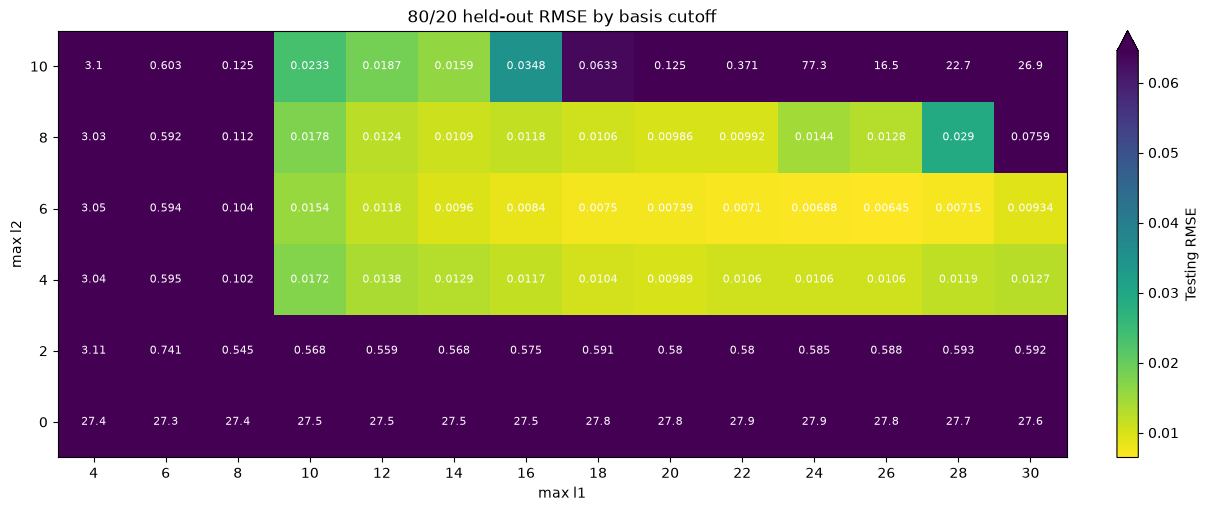

In [8]:
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib-cache"))

import matplotlib.pyplot as plt


max_l1_grid = list(range(4, 31, 2))
max_l2_grid = list(range(0, 11, 2))

sweep_result = run_basis_cutoff_sweep(training_data, testing_data, max_l1_grid, max_l2_grid)

# Keep these names available for downstream inspection.
test_rmse_grid = sweep_result["test_rmse_grid"]
train_rmse_grid = sweep_result["train_rmse_grid"]
test_relative_rmse_grid = sweep_result["test_relative_rmse_grid"]
train_relative_rmse_grid = sweep_result["train_relative_rmse_grid"]
term_count_grid = sweep_result["term_count_grid"]
rank_grid = sweep_result["rank_grid"]
split_fit_results = sweep_result["split_fit_results"]
color_min = sweep_result["color_min"]
color_max = sweep_result["color_max"]
best_l2_index = sweep_result["best_l2_index"]
best_l1_index = sweep_result["best_l1_index"]
best_max_l1 = sweep_result["best_max_l1"]
best_max_l2 = sweep_result["best_max_l2"]
best_result = sweep_result["best_result"]

plot_sweep_rmse_heatmap(sweep_result)
print_sweep_best(sweep_result)

plt.show()


## Capping terms in the training/testing split

Best capped testing RMSE: 0.0099936375
Best capped testing relative RMSE: 0.00016909028
Best capped training relative RMSE: 0.00016824592
Best capped max_l1: 18
Best capped max_l2: 4
Terms in best capped fit: 120
Training rank in best capped fit: 78


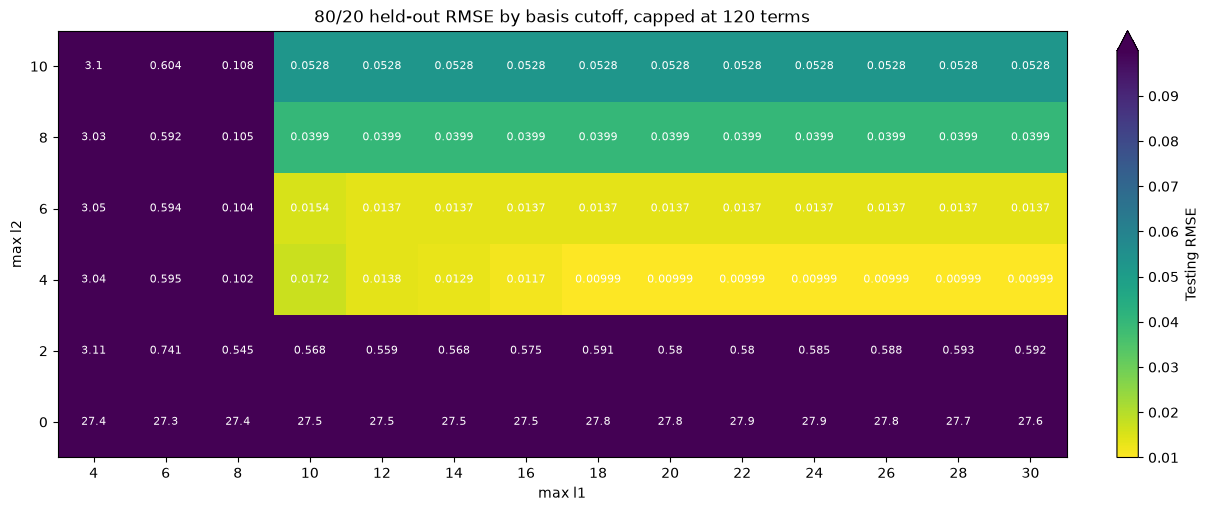

In [9]:
terms_cap = 120

capped_sweep_result = run_basis_cutoff_sweep(
    training_data,
    testing_data,
    max_l1_grid,
    max_l2_grid,
    terms_cap=terms_cap,
)

# Keep these names available for downstream inspection.
capped_test_rmse_grid = capped_sweep_result["test_rmse_grid"]
capped_train_rmse_grid = capped_sweep_result["train_rmse_grid"]
capped_test_relative_rmse_grid = capped_sweep_result["test_relative_rmse_grid"]
capped_train_relative_rmse_grid = capped_sweep_result["train_relative_rmse_grid"]
capped_term_count_grid = capped_sweep_result["term_count_grid"]
capped_rank_grid = capped_sweep_result["rank_grid"]
capped_split_fit_results = capped_sweep_result["split_fit_results"]
capped_color_min = capped_sweep_result["color_min"]
capped_color_max = capped_sweep_result["color_max"]
capped_best_l2_index = capped_sweep_result["best_l2_index"]
capped_best_l1_index = capped_sweep_result["best_l1_index"]
capped_best_max_l1 = capped_sweep_result["best_max_l1"]
capped_best_max_l2 = capped_sweep_result["best_max_l2"]
capped_best_result = capped_sweep_result["best_result"]

plot_sweep_rmse_heatmap(capped_sweep_result)
print_sweep_best(capped_sweep_result, label="capped")

plt.show()


## Selecting the ``most important" terms.

We can perform the fitting without specifying a max number of terms, and then we will have $l1 \cdot l2/4$ terms. From here, we can hold out terms to determine which ones are the most important.  

R = 4.4
Best R-slice testing RMSE: 31.348064
Best R-slice testing relative RMSE: 0.0010238565
Best R-slice training relative RMSE: 0.00080762486
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


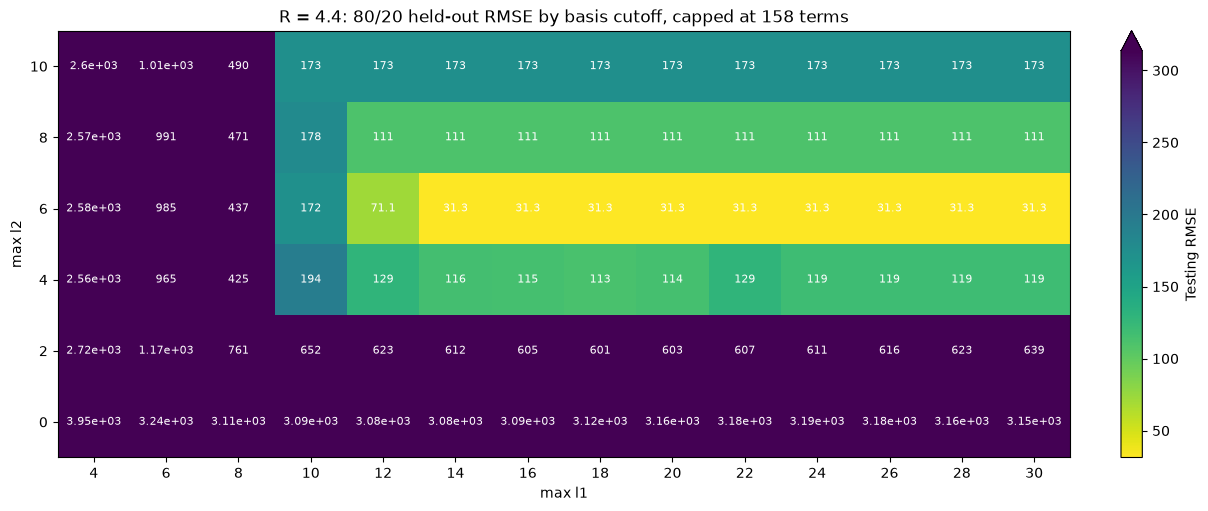

R = 4.6
Best R-slice testing RMSE: 12.568075
Best R-slice testing relative RMSE: 0.00056509106
Best R-slice training relative RMSE: 0.0004402228
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


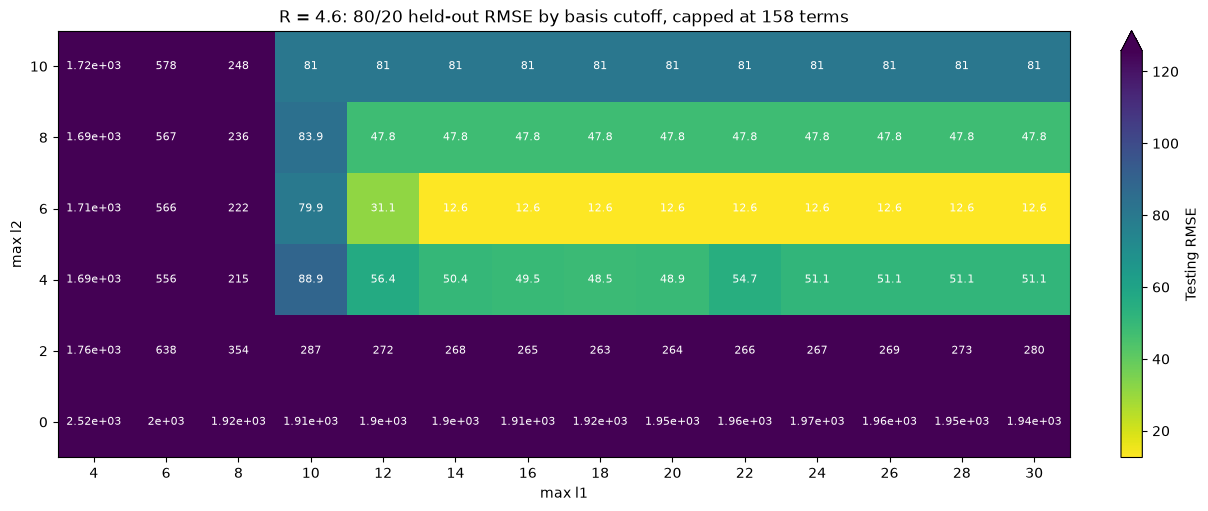

R = 4.8
Best R-slice testing RMSE: 5.3105253
Best R-slice testing relative RMSE: 0.00033104324
Best R-slice training relative RMSE: 0.00025580199
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


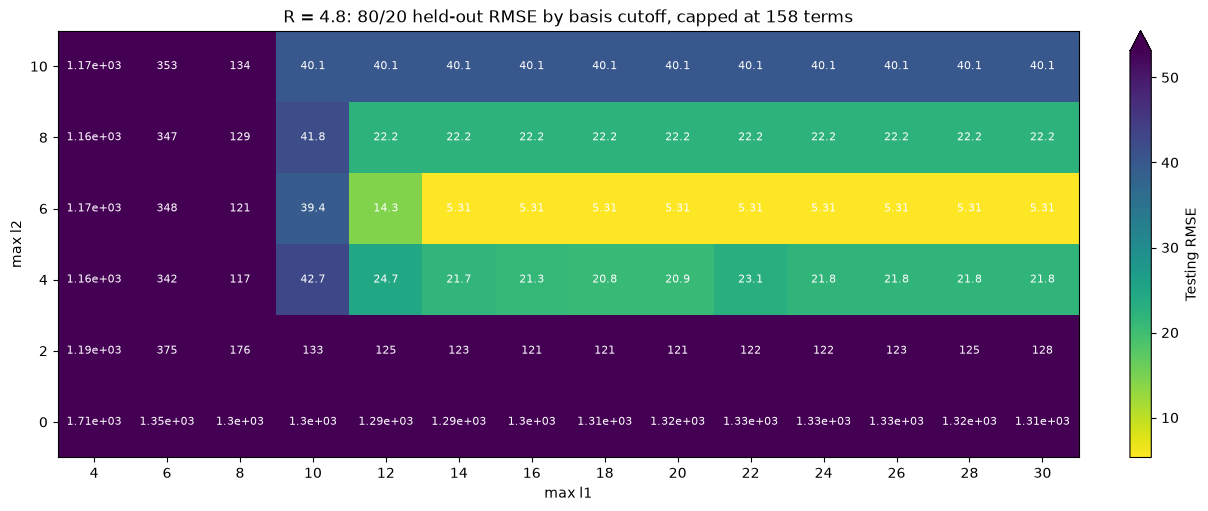

R = 5
Best R-slice testing RMSE: 2.3756474
Best R-slice testing relative RMSE: 0.00020748297
Best R-slice training relative RMSE: 0.00015799335
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


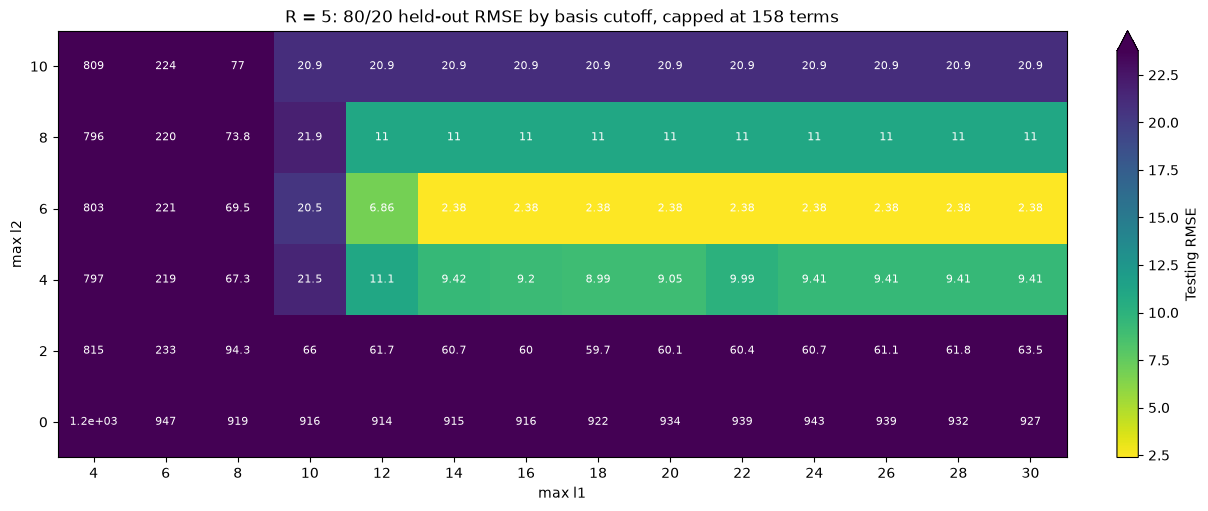

R = 5.2
Best R-slice testing RMSE: 1.1244347
Best R-slice testing relative RMSE: 0.00013924125
Best R-slice training relative RMSE: 0.00010525507
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


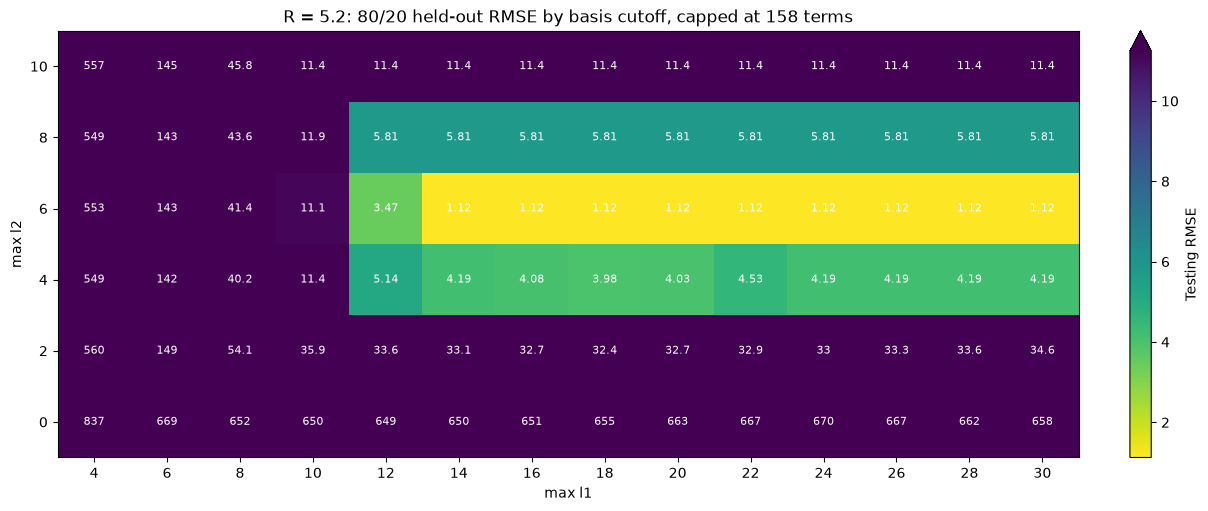

R = 5.4
Best R-slice testing RMSE: 0.5703223
Best R-slice testing relative RMSE: 0.0001014194
Best R-slice training relative RMSE: 7.6940205e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


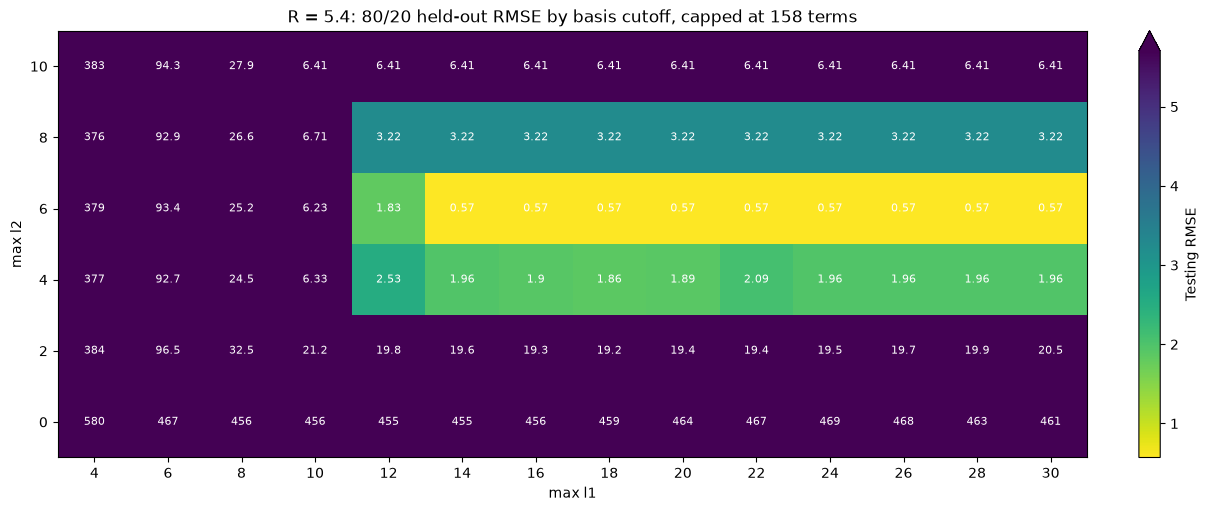

R = 5.6
Best R-slice testing RMSE: 0.32034573
Best R-slice testing relative RMSE: 8.2928887e-05
Best R-slice training relative RMSE: 6.3265346e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


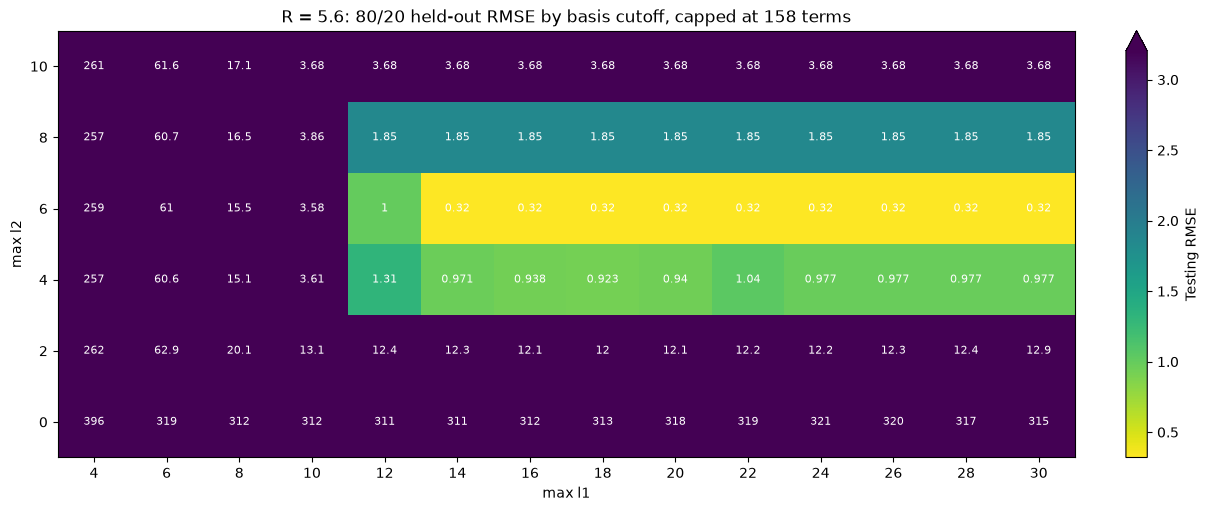

R = 5.8
Best R-slice testing RMSE: 0.19901144
Best R-slice testing relative RMSE: 7.6131951e-05
Best R-slice training relative RMSE: 5.8121679e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 6
Terms in best R-slice fit: 158
Training rank in best R-slice fit: 106


KeyboardInterrupt: 

In [10]:
all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
all_r_values = numpy.unique(all_data[:, 0])

# Use the same l1/l2 grid as above. Set this to None for the uncapped sweep.
all_r_terms_cap = 158
all_r_train_fraction = train_fraction
all_r_random_seed = random_seed

all_r_sweep_results = {}

for r_value in all_r_values:
    r_data = all_data[all_data[:, 0] == r_value]
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=all_r_train_fraction,
        random_seed=all_r_random_seed,
    )

    r_sweep_result = run_basis_cutoff_sweep(
        r_training_data,
        r_testing_data,
        max_l1_grid,
        max_l2_grid,
        terms_cap=all_r_terms_cap,
    )
    all_r_sweep_results[float(r_value)] = r_sweep_result

    cap_label = "uncapped" if all_r_terms_cap is None else f"capped at {all_r_terms_cap} terms"
    plot_sweep_rmse_heatmap(
        r_sweep_result,
        title=f"R = {r_value:g}: 80/20 held-out RMSE by basis cutoff, {cap_label}",
    )
    print(f"R = {r_value:g}")
    print_sweep_best(r_sweep_result, label="R-slice")
    plt.show()


R = 4.4
Best R-slice testing RMSE: 3.1946874
Best R-slice testing relative RMSE: 0.00010434142
Best R-slice training relative RMSE: 3.7888998e-05
Best R-slice max_l1: 22
Best R-slice max_l2: 8
Terms in best R-slice fit: 460
Training rank in best R-slice fit: 270


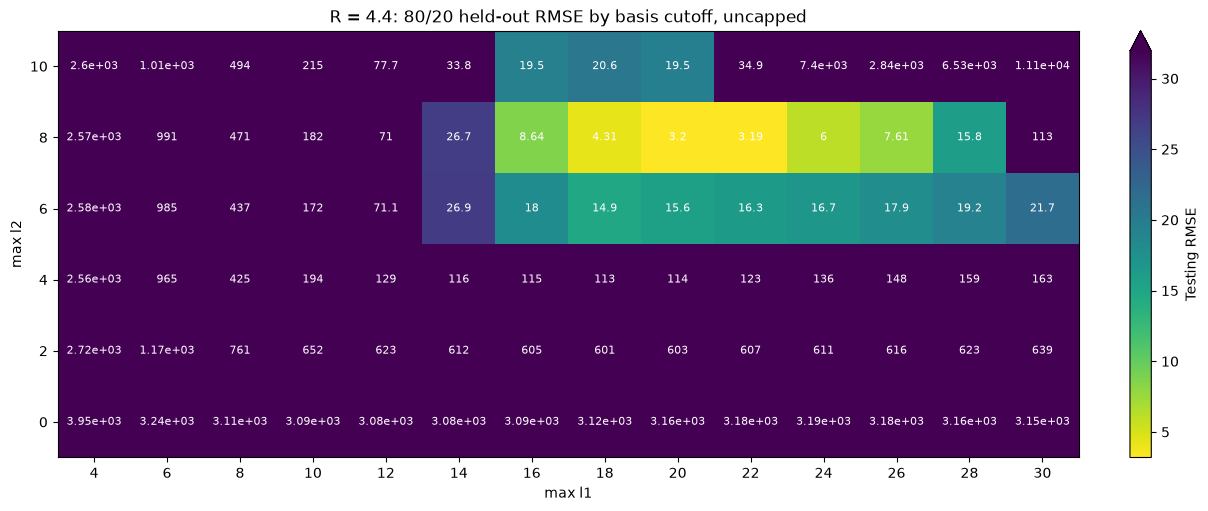

R = 4.6
Best R-slice testing RMSE: 1.001223
Best R-slice testing relative RMSE: 4.5017407e-05
Best R-slice training relative RMSE: 1.8989375e-05
Best R-slice max_l1: 20
Best R-slice max_l2: 8
Terms in best R-slice fit: 415
Training rank in best R-slice fit: 248


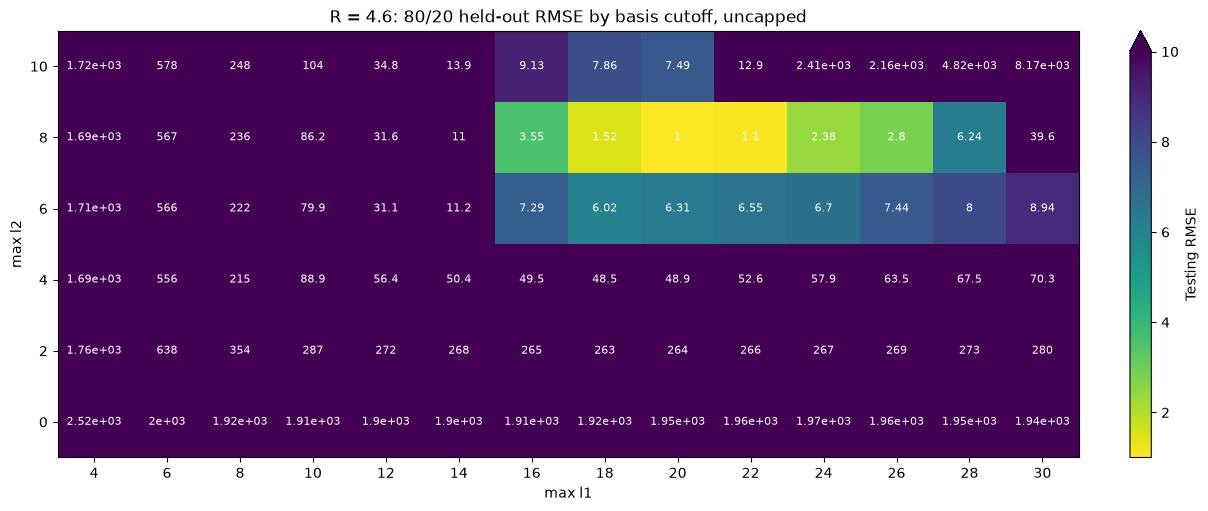

R = 4.8
Best R-slice testing RMSE: 0.37507923
Best R-slice testing relative RMSE: 2.3381386e-05
Best R-slice training relative RMSE: 1.1778589e-05
Best R-slice max_l1: 20
Best R-slice max_l2: 8
Terms in best R-slice fit: 415
Training rank in best R-slice fit: 248


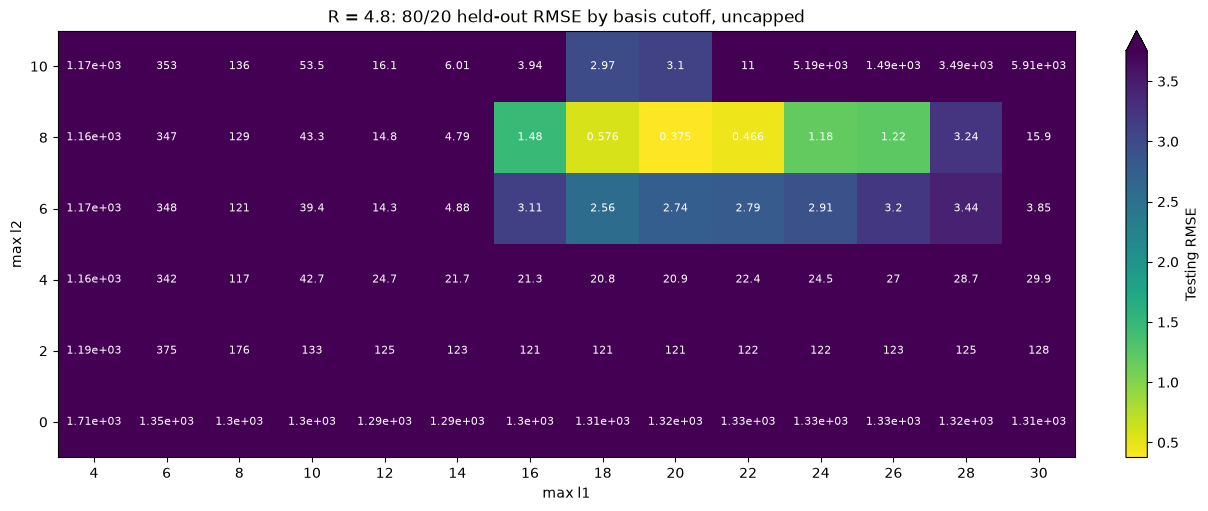

R = 5
Best R-slice testing RMSE: 0.17906566
Best R-slice testing relative RMSE: 1.5639137e-05
Best R-slice training relative RMSE: 8.188691e-06
Best R-slice max_l1: 20
Best R-slice max_l2: 8
Terms in best R-slice fit: 415
Training rank in best R-slice fit: 248


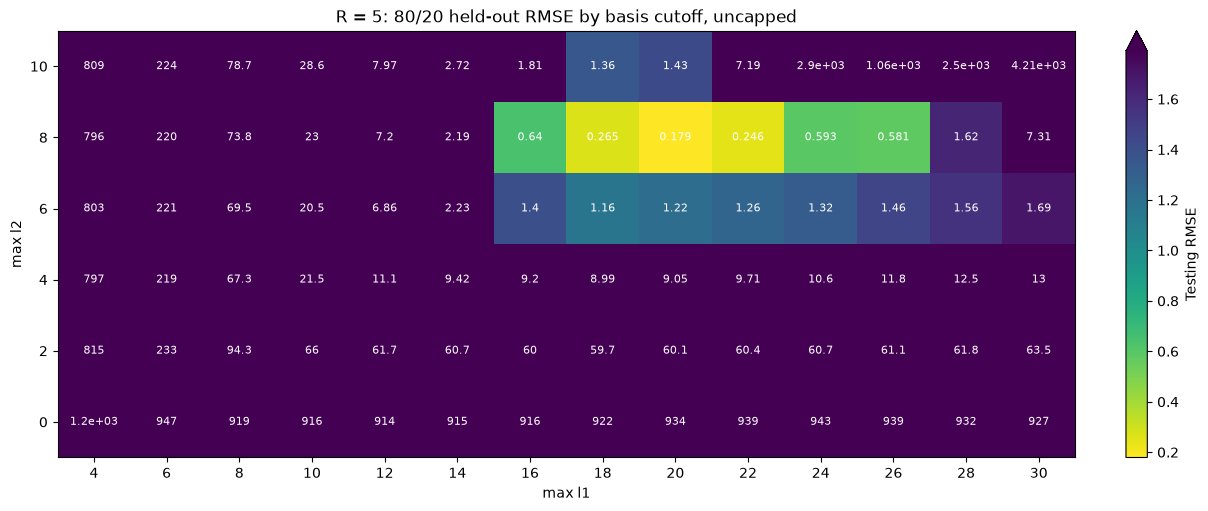

R = 5.2
Best R-slice testing RMSE: 0.11865717
Best R-slice testing relative RMSE: 1.4693582e-05
Best R-slice training relative RMSE: 5.9526976e-06
Best R-slice max_l1: 20
Best R-slice max_l2: 8
Terms in best R-slice fit: 415
Training rank in best R-slice fit: 248


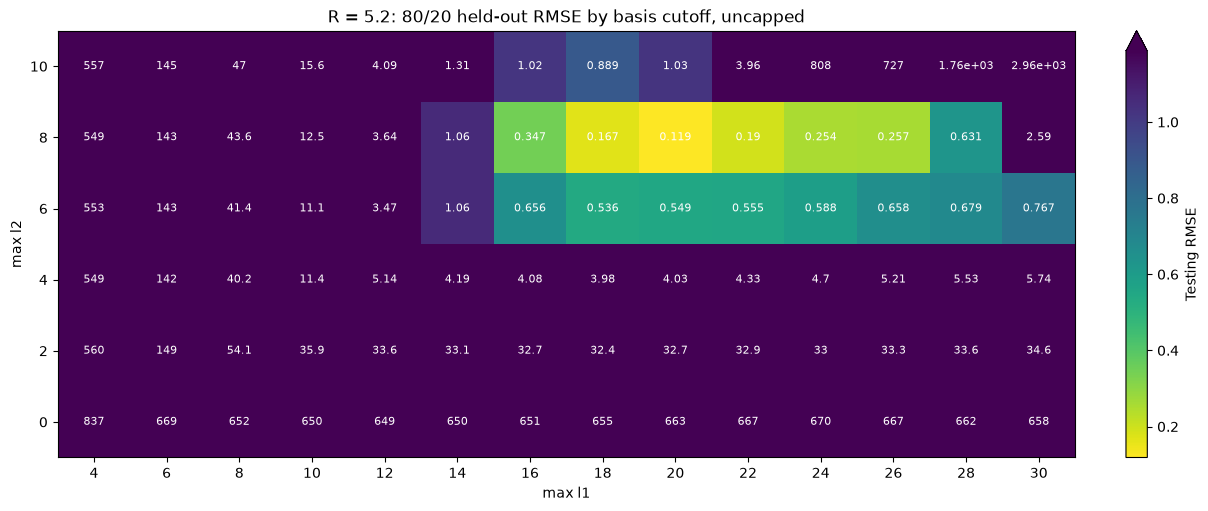

R = 5.4
Best R-slice testing RMSE: 0.10133985
Best R-slice testing relative RMSE: 1.8021086e-05
Best R-slice training relative RMSE: 3.7095691e-06
Best R-slice max_l1: 24
Best R-slice max_l2: 8
Terms in best R-slice fit: 505
Training rank in best R-slice fit: 295


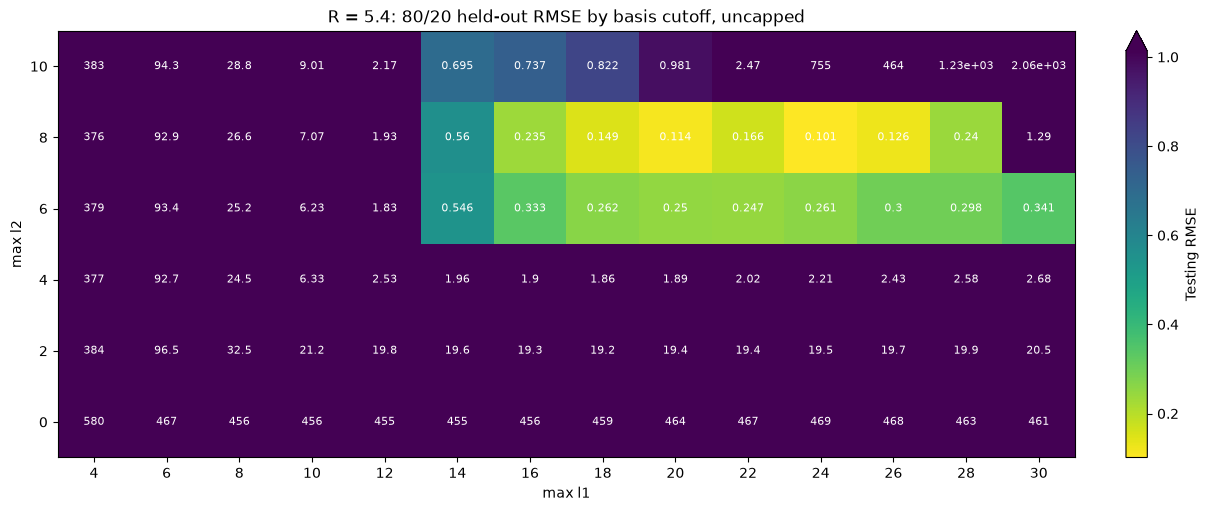

R = 5.6
Best R-slice testing RMSE: 0.10024516
Best R-slice testing relative RMSE: 2.5950774e-05
Best R-slice training relative RMSE: 4.7619516e-06
Best R-slice max_l1: 24
Best R-slice max_l2: 8
Terms in best R-slice fit: 505
Training rank in best R-slice fit: 295


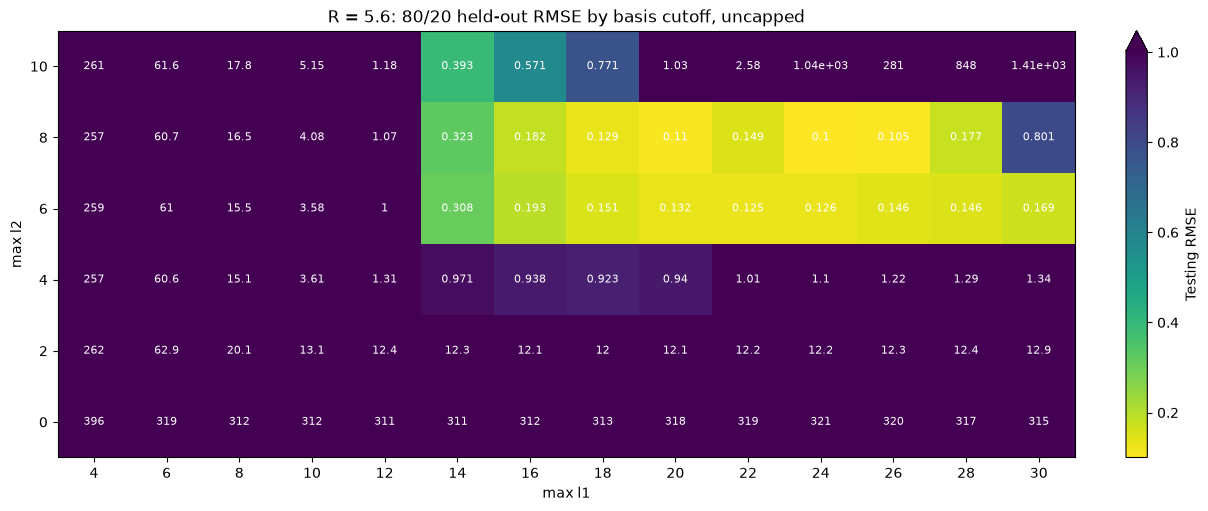

R = 5.8
Best R-slice testing RMSE: 0.077943563
Best R-slice testing relative RMSE: 2.9817359e-05
Best R-slice training relative RMSE: 1.4919463e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


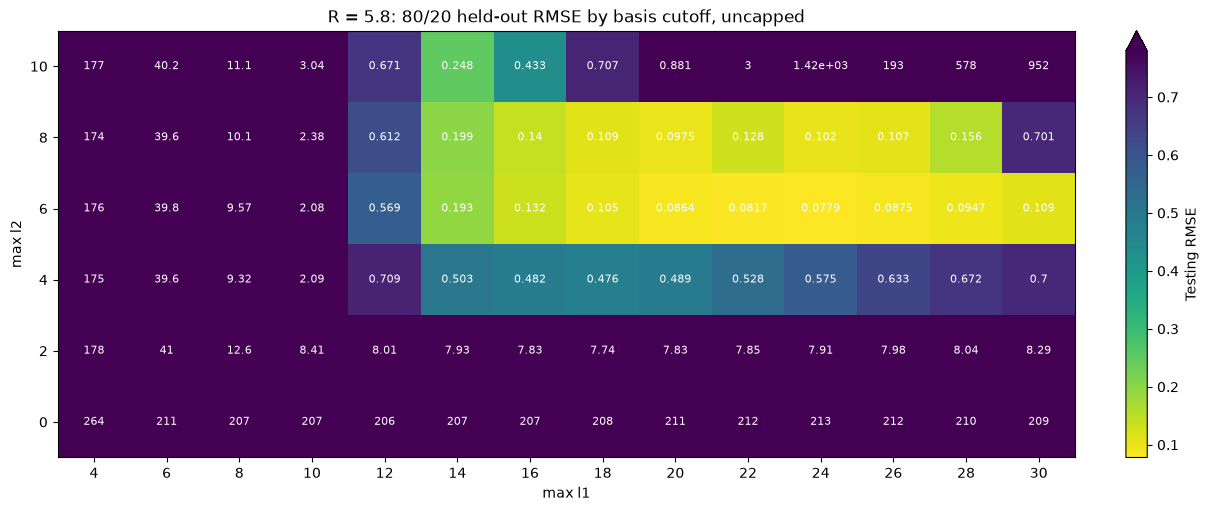

R = 6
Best R-slice testing RMSE: 0.056901187
Best R-slice testing relative RMSE: 3.2725604e-05
Best R-slice training relative RMSE: 1.6181812e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


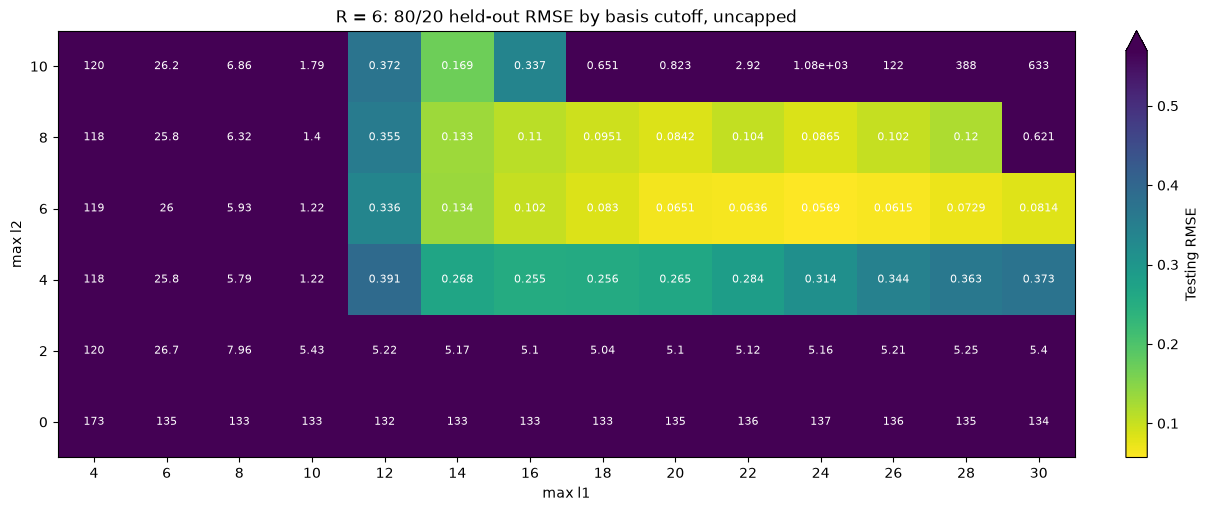

R = 6.2
Best R-slice testing RMSE: 0.042181837
Best R-slice testing relative RMSE: 3.7235106e-05
Best R-slice training relative RMSE: 1.9177481e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


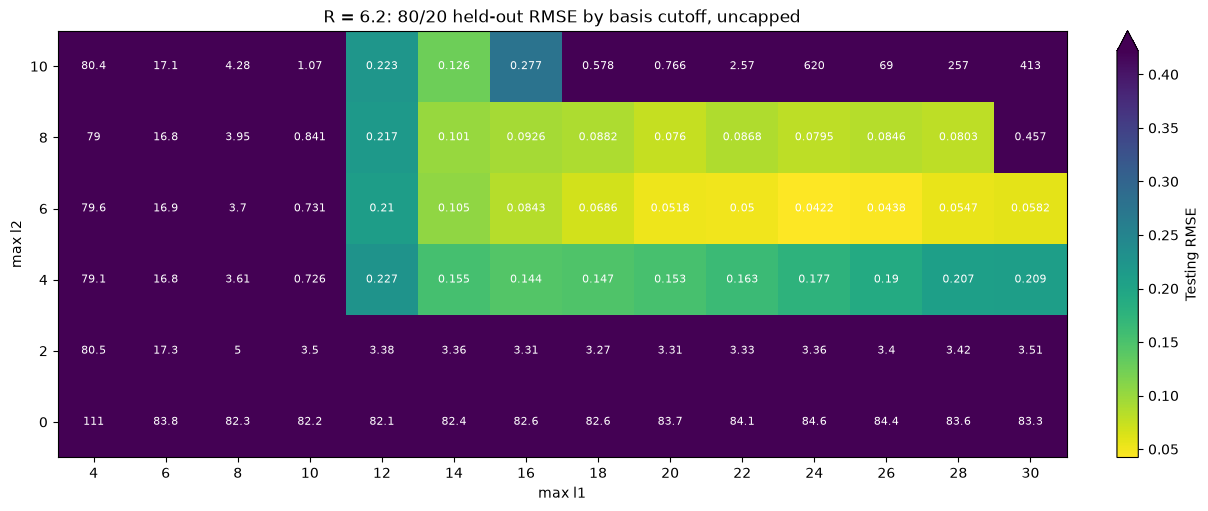

R = 6.4
Best R-slice testing RMSE: 0.029966283
Best R-slice testing relative RMSE: 4.1670433e-05
Best R-slice training relative RMSE: 2.3562498e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


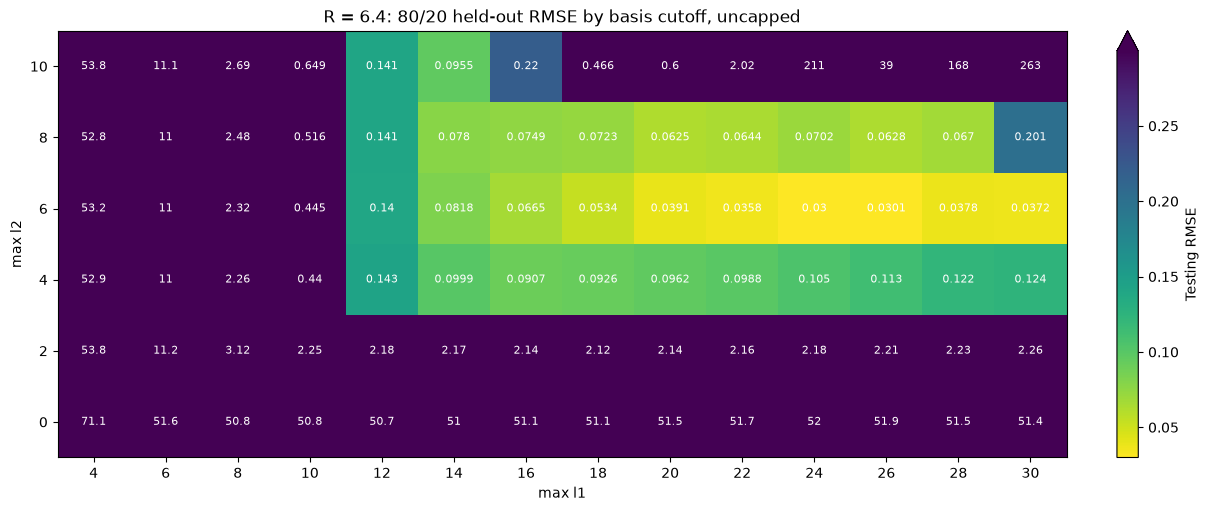

R = 6.6
Best R-slice testing RMSE: 0.019957101
Best R-slice testing relative RMSE: 4.5235545e-05
Best R-slice training relative RMSE: 2.9374597e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


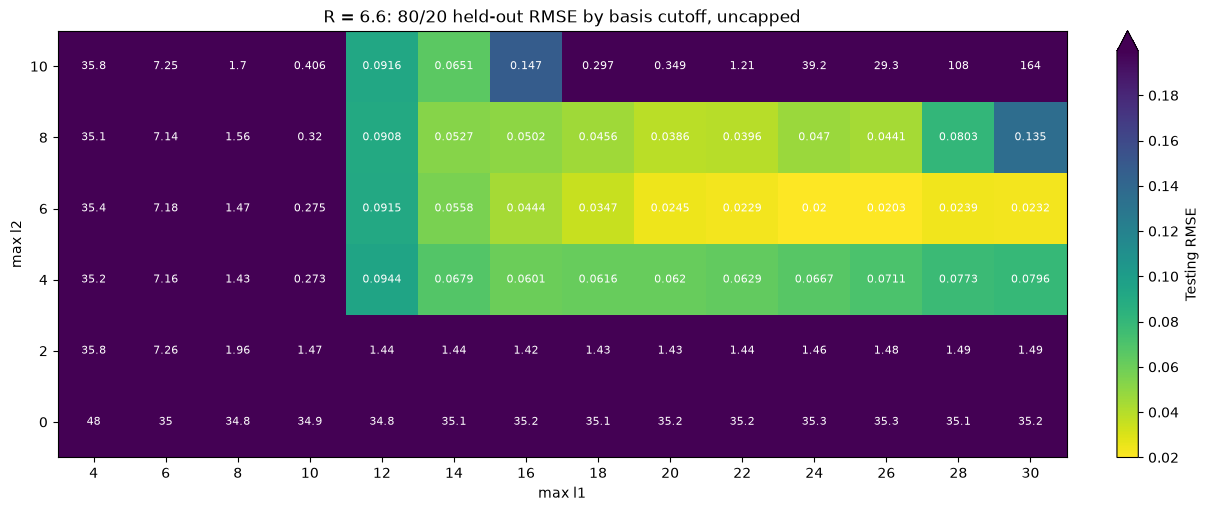

R = 6.8
Best R-slice testing RMSE: 0.014322064
Best R-slice testing relative RMSE: 5.5370855e-05
Best R-slice training relative RMSE: 3.848426e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


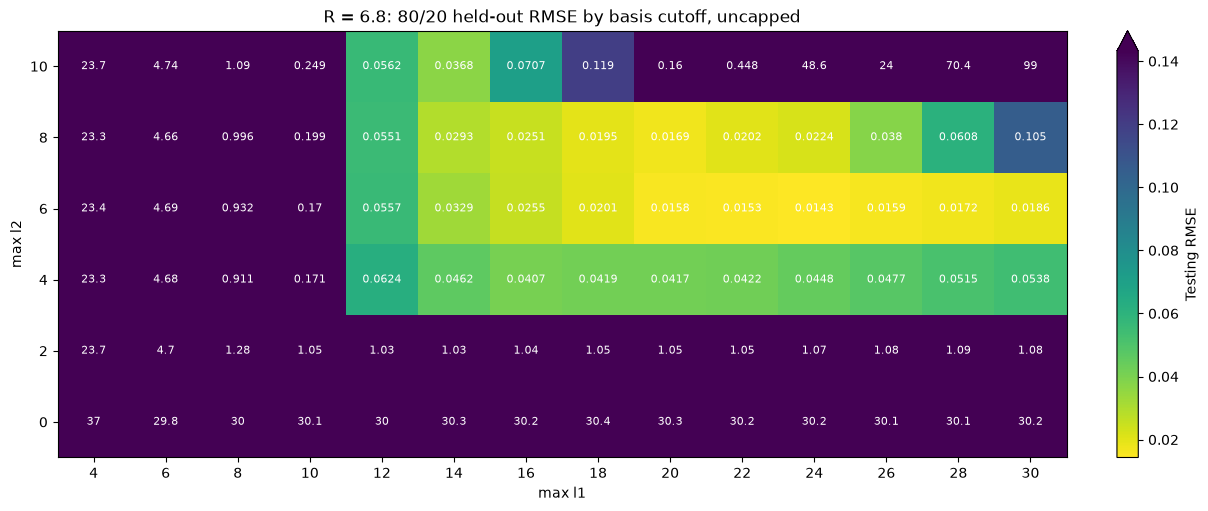

R = 7
Best R-slice testing RMSE: 0.014177217
Best R-slice testing relative RMSE: 9.865424e-05
Best R-slice training relative RMSE: 6.0673167e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


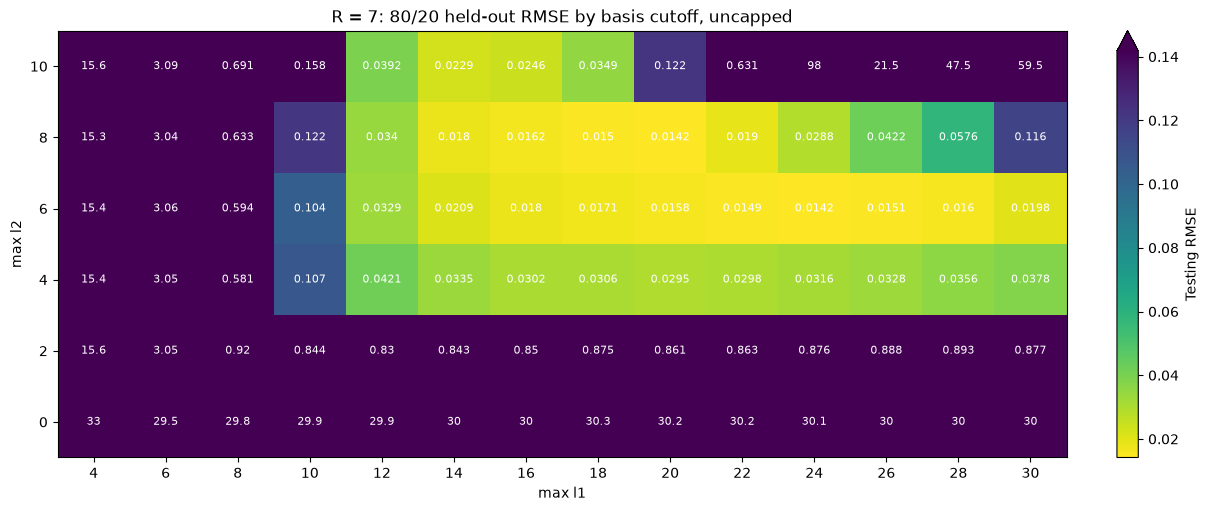

R = 7.25
Best R-slice testing RMSE: 0.014422307
Best R-slice testing relative RMSE: 0.00020631944
Best R-slice training relative RMSE: 0.00010430648
Best R-slice max_l1: 26
Best R-slice max_l2: 6
Terms in best R-slice fit: 352
Training rank in best R-slice fit: 214


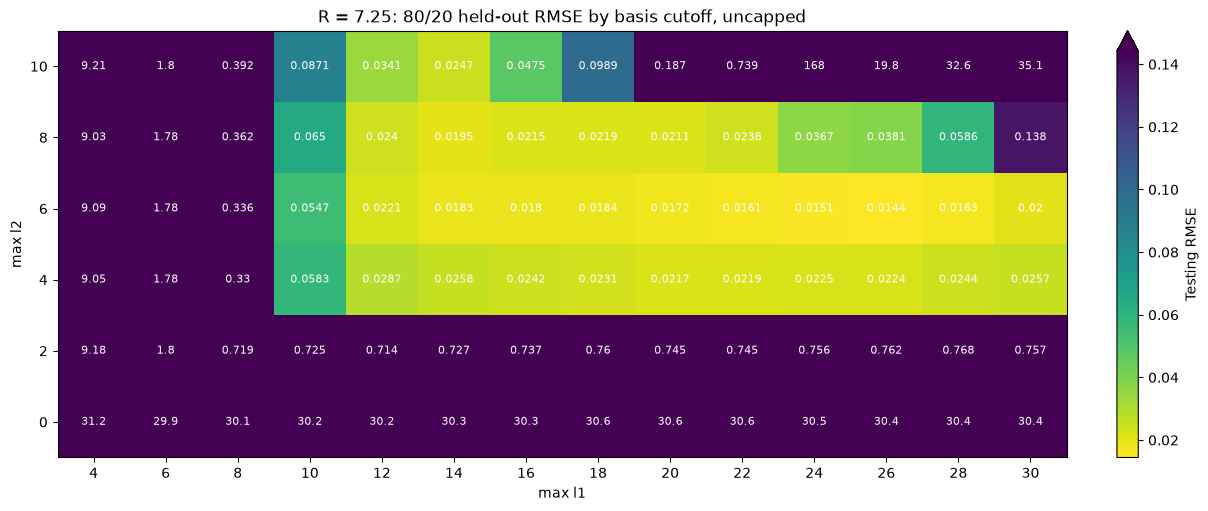

R = 7.5
Best R-slice testing RMSE: 0.010981314
Best R-slice testing relative RMSE: 0.00020156415
Best R-slice training relative RMSE: 9.8088192e-05
Best R-slice max_l1: 26
Best R-slice max_l2: 6
Terms in best R-slice fit: 352
Training rank in best R-slice fit: 214


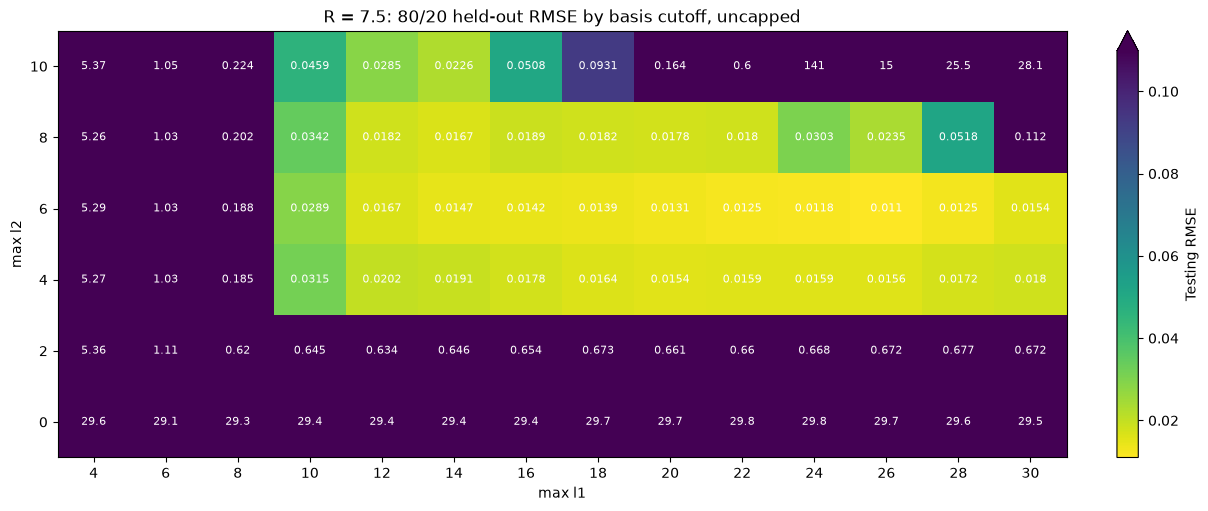

R = 7.75
Best R-slice testing RMSE: 0.0064518027
Best R-slice testing relative RMSE: 0.00010916317
Best R-slice training relative RMSE: 5.3973111e-05
Best R-slice max_l1: 26
Best R-slice max_l2: 6
Terms in best R-slice fit: 352
Training rank in best R-slice fit: 214


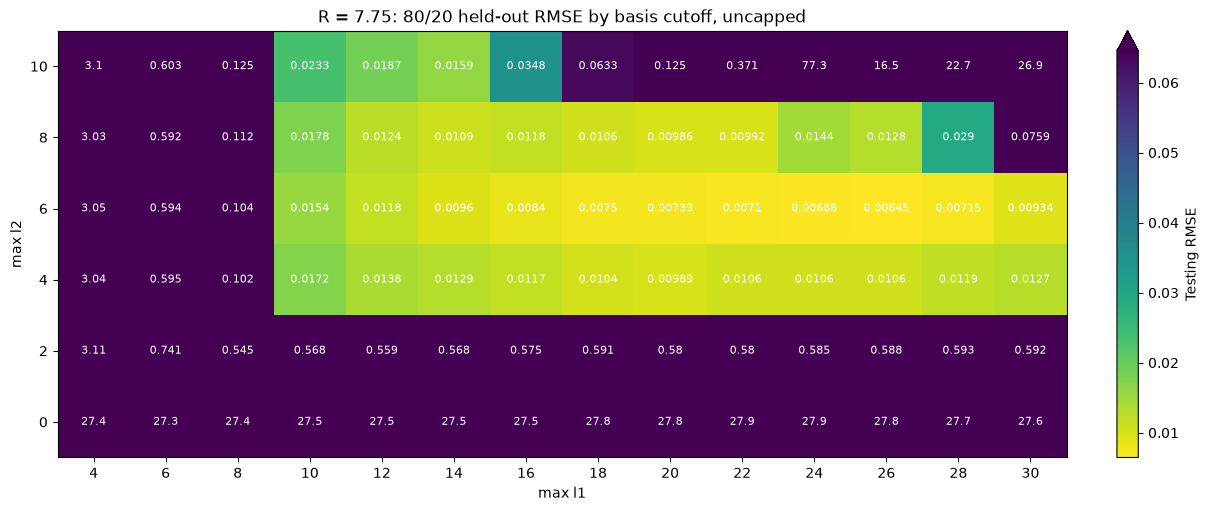

R = 8
Best R-slice testing RMSE: 0.0033630493
Best R-slice testing relative RMSE: 5.4941982e-05
Best R-slice training relative RMSE: 2.6158318e-05
Best R-slice max_l1: 26
Best R-slice max_l2: 6
Terms in best R-slice fit: 352
Training rank in best R-slice fit: 214


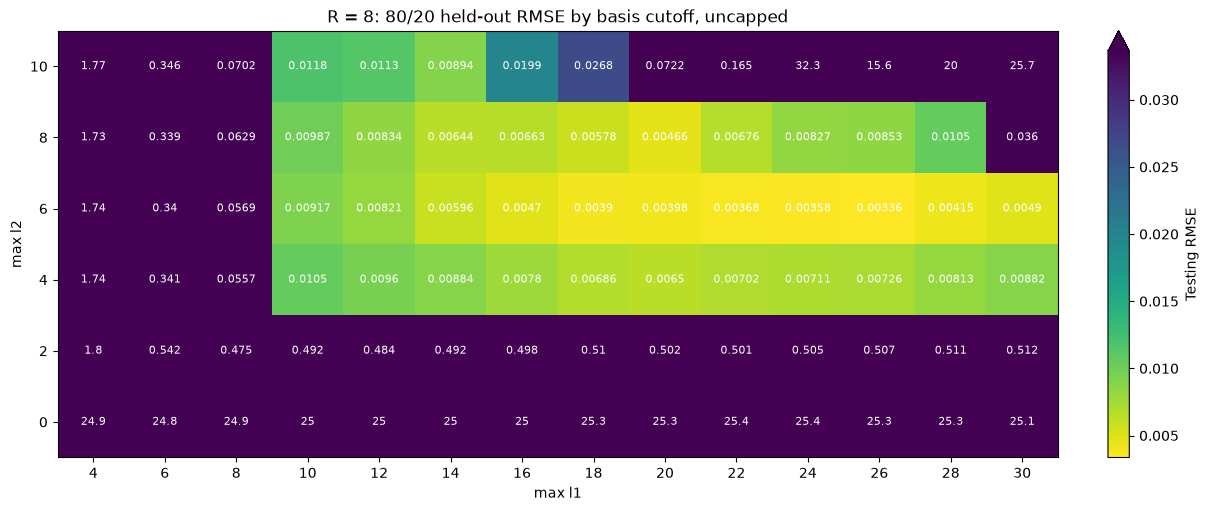

R = 8.5
Best R-slice testing RMSE: 0.0018527179
Best R-slice testing relative RMSE: 3.4246428e-05
Best R-slice training relative RMSE: 1.8845352e-05
Best R-slice max_l1: 24
Best R-slice max_l2: 6
Terms in best R-slice fit: 324
Training rank in best R-slice fit: 198


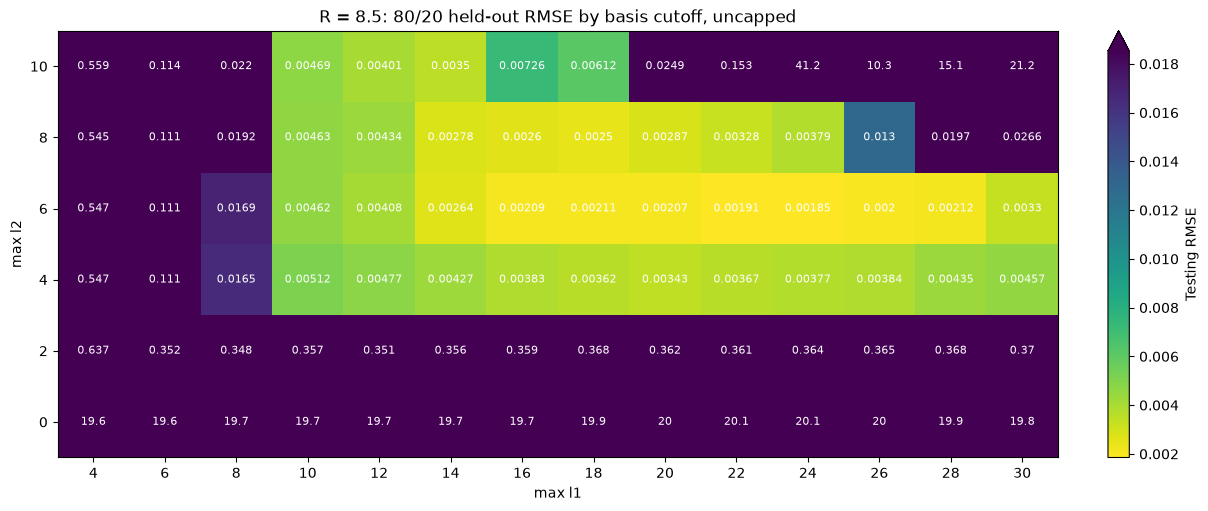

R = 9
Best R-slice testing RMSE: 0.0015073344
Best R-slice testing relative RMSE: 3.588695e-05
Best R-slice training relative RMSE: 2.5655428e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 8
Terms in best R-slice fit: 280
Training rank in best R-slice fit: 169


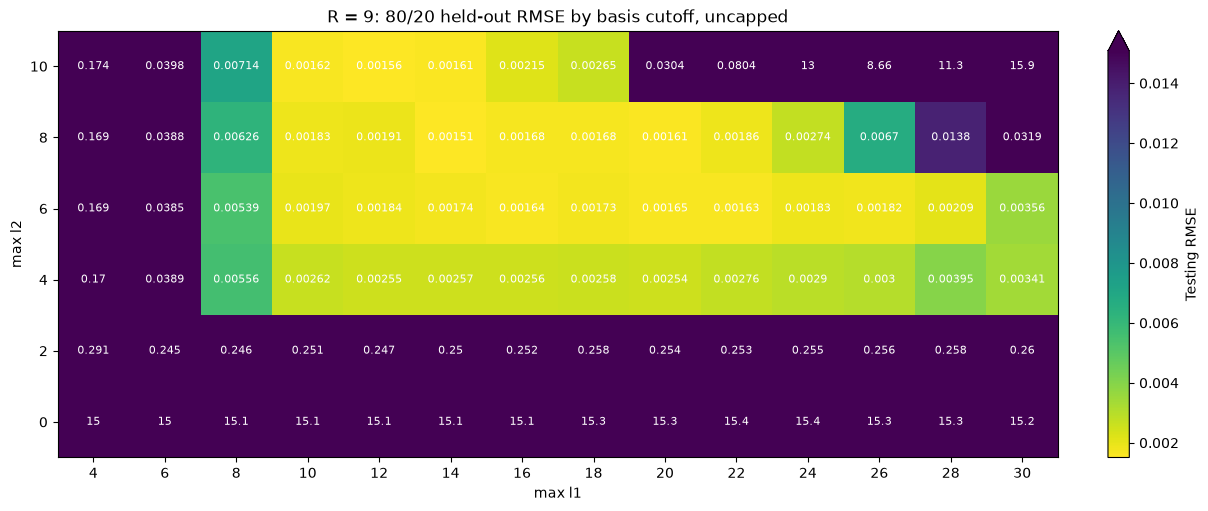

R = 9.5
Best R-slice testing RMSE: 0.00073422543
Best R-slice testing relative RMSE: 2.3651836e-05
Best R-slice training relative RMSE: 1.7088413e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 8
Terms in best R-slice fit: 280
Training rank in best R-slice fit: 169


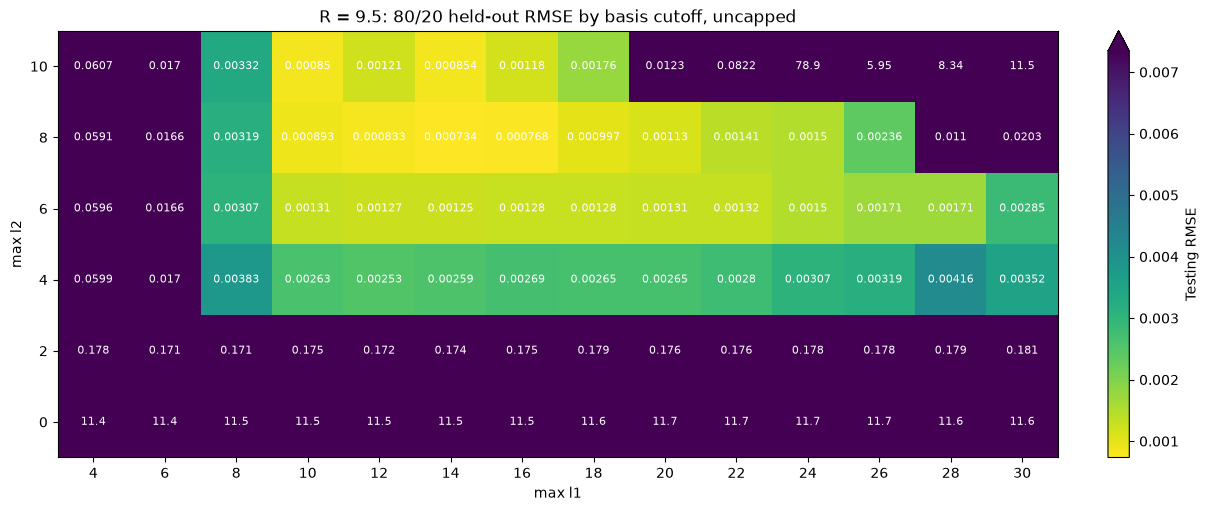

R = 10
Best R-slice testing RMSE: 0.00040876724
Best R-slice testing relative RMSE: 1.8058446e-05
Best R-slice training relative RMSE: 8.7165401e-06
Best R-slice max_l1: 14
Best R-slice max_l2: 10
Terms in best R-slice fit: 388
Training rank in best R-slice fit: 231


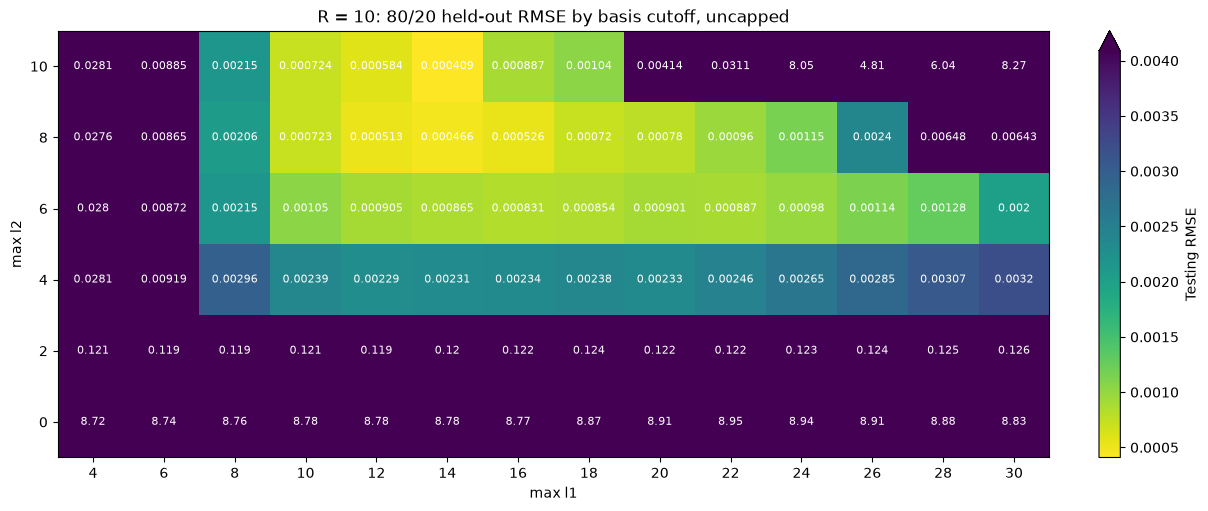

R = 11
Best R-slice testing RMSE: 0.00044767504
Best R-slice testing relative RMSE: 3.654528e-05
Best R-slice training relative RMSE: 2.2845688e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 8
Terms in best R-slice fit: 280
Training rank in best R-slice fit: 169


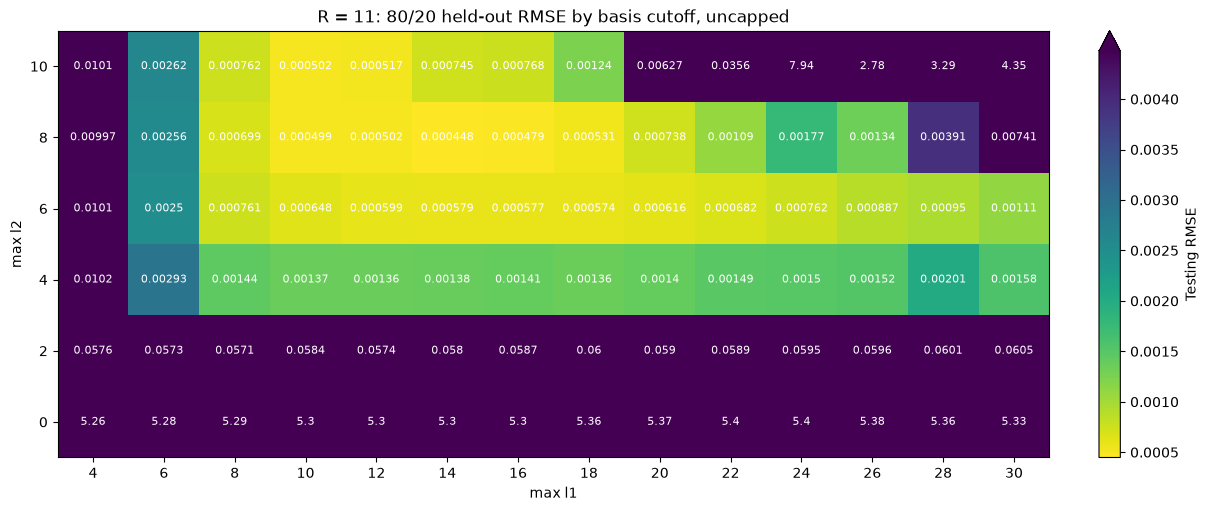

R = 12
Best R-slice testing RMSE: 0.00041264553
Best R-slice testing relative RMSE: 5.8993355e-05
Best R-slice training relative RMSE: 3.8363107e-05
Best R-slice max_l1: 14
Best R-slice max_l2: 8
Terms in best R-slice fit: 280
Training rank in best R-slice fit: 169


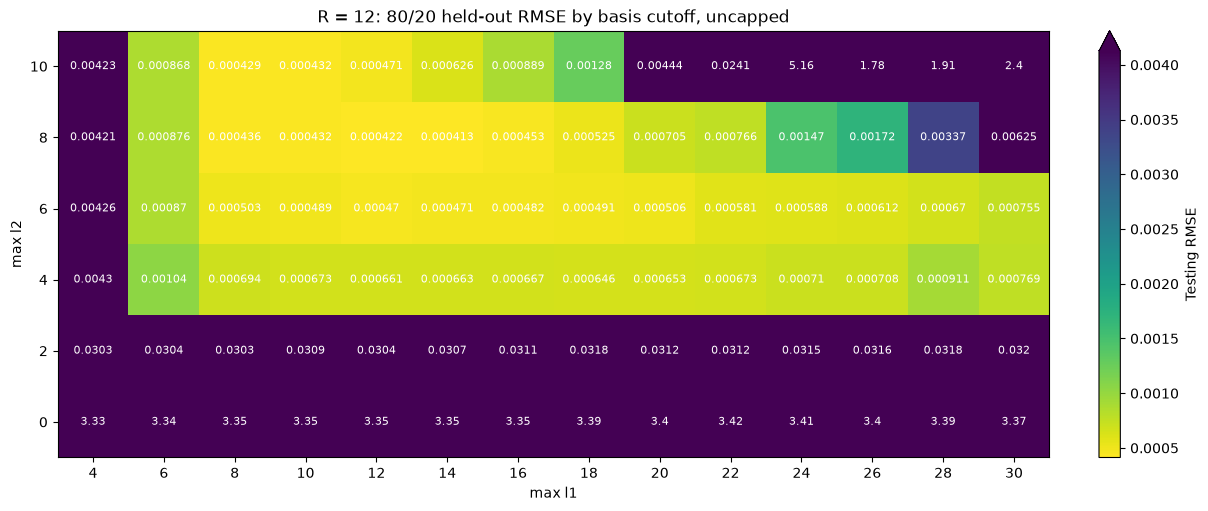

R = 13
Best R-slice testing RMSE: 0.00034662598
Best R-slice testing relative RMSE: 8.207482e-05
Best R-slice training relative RMSE: 5.8955214e-05
Best R-slice max_l1: 8
Best R-slice max_l2: 10
Terms in best R-slice fit: 190
Training rank in best R-slice fit: 120


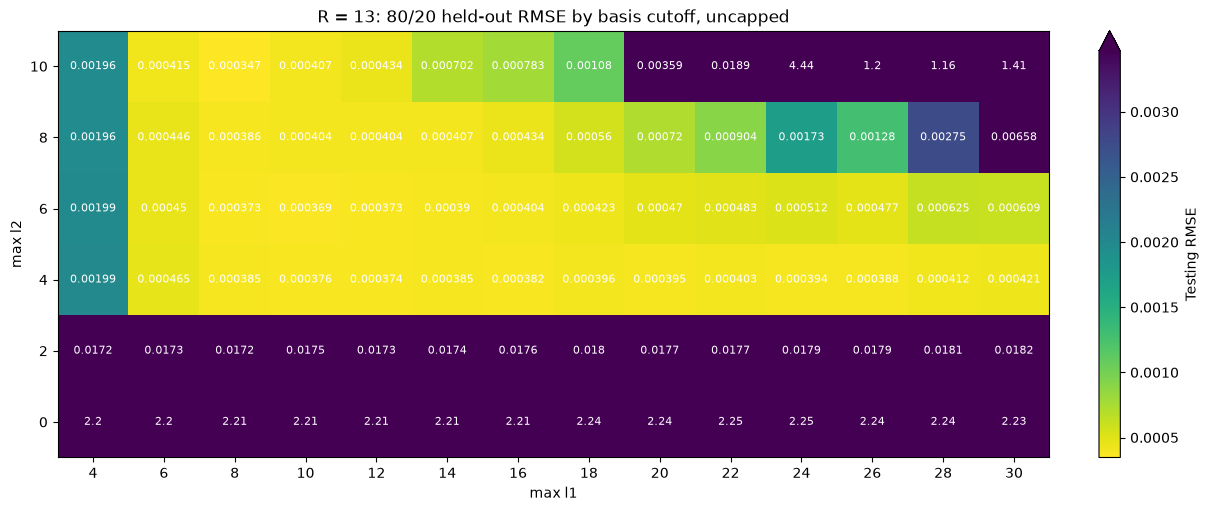

R = 14
Best R-slice testing RMSE: 0.00027294545
Best R-slice testing relative RMSE: 0.00010211659
Best R-slice training relative RMSE: 9.8266727e-05
Best R-slice max_l1: 6
Best R-slice max_l2: 10
Terms in best R-slice fit: 128
Training rank in best R-slice fit: 77


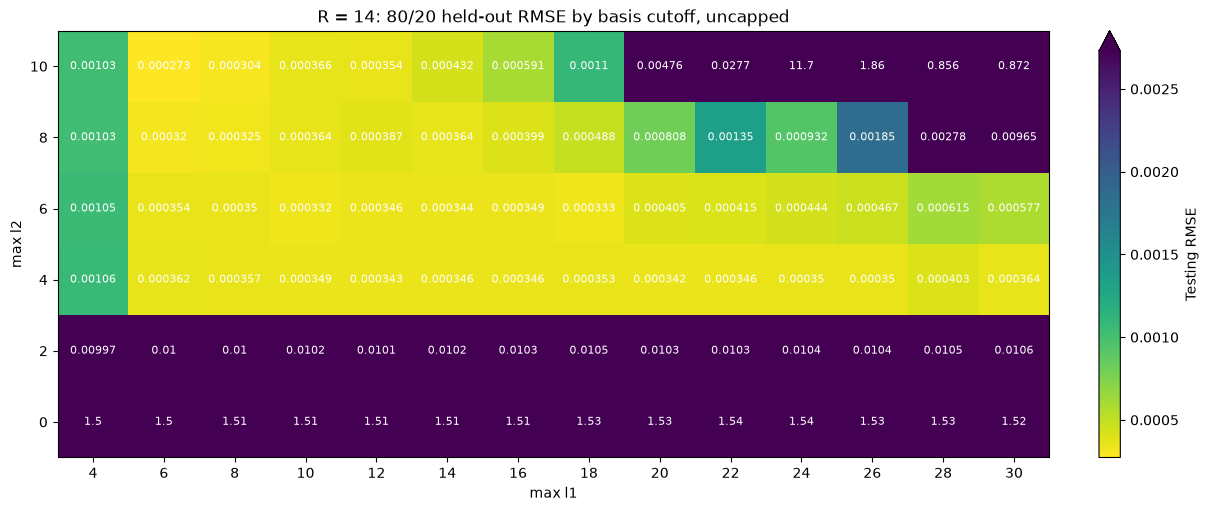

R = 15
Best R-slice testing RMSE: 0.00025319798
Best R-slice testing relative RMSE: 0.00014411212
Best R-slice training relative RMSE: 0.00013677763
Best R-slice max_l1: 6
Best R-slice max_l2: 10
Terms in best R-slice fit: 128
Training rank in best R-slice fit: 77


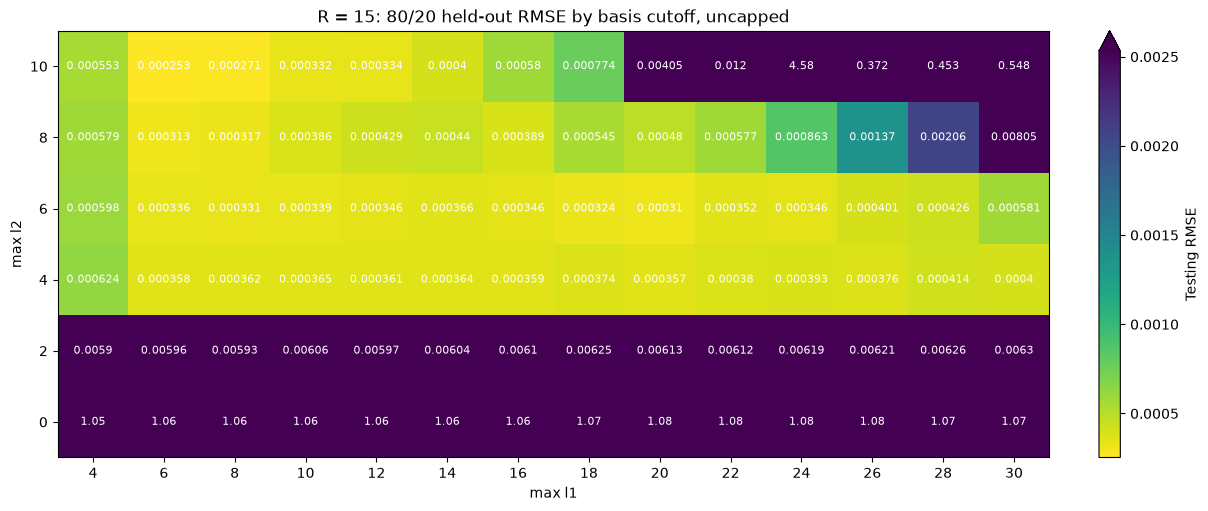

R = 20
Best R-slice testing RMSE: 0.00015048478
Best R-slice testing relative RMSE: 0.00048866465
Best R-slice training relative RMSE: 0.00041158002
Best R-slice max_l1: 6
Best R-slice max_l2: 10
Terms in best R-slice fit: 128
Training rank in best R-slice fit: 77


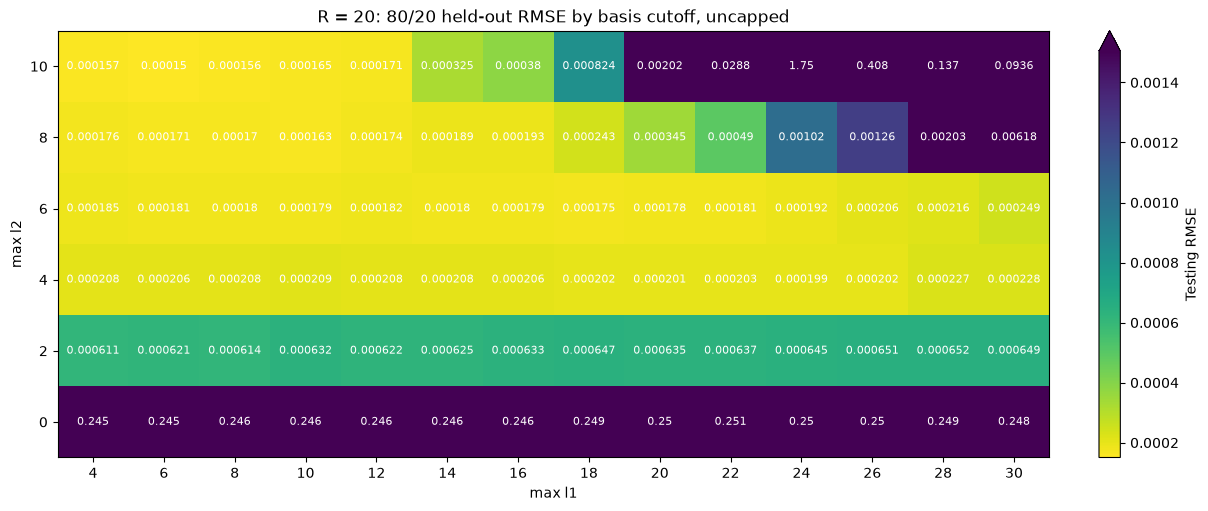

R = 30
Best R-slice testing RMSE: 7.1207908e-06
Best R-slice testing relative RMSE: 0.00010069937
Best R-slice training relative RMSE: 7.2616217e-05
Best R-slice max_l1: 18
Best R-slice max_l2: 4
Terms in best R-slice fit: 134
Training rank in best R-slice fit: 84


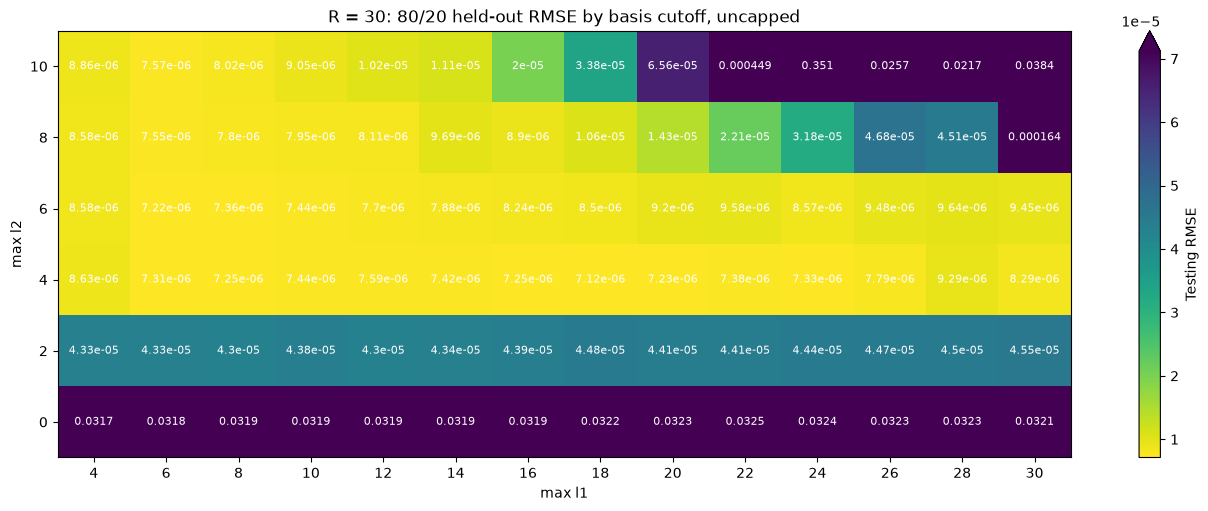

R = 40
Best R-slice testing RMSE: 5.2140674e-06
Best R-slice testing relative RMSE: 6.5457103e-05
Best R-slice training relative RMSE: 6.7157935e-05
Best R-slice max_l1: 10
Best R-slice max_l2: 4
Terms in best R-slice fit: 74
Training rank in best R-slice fit: 47


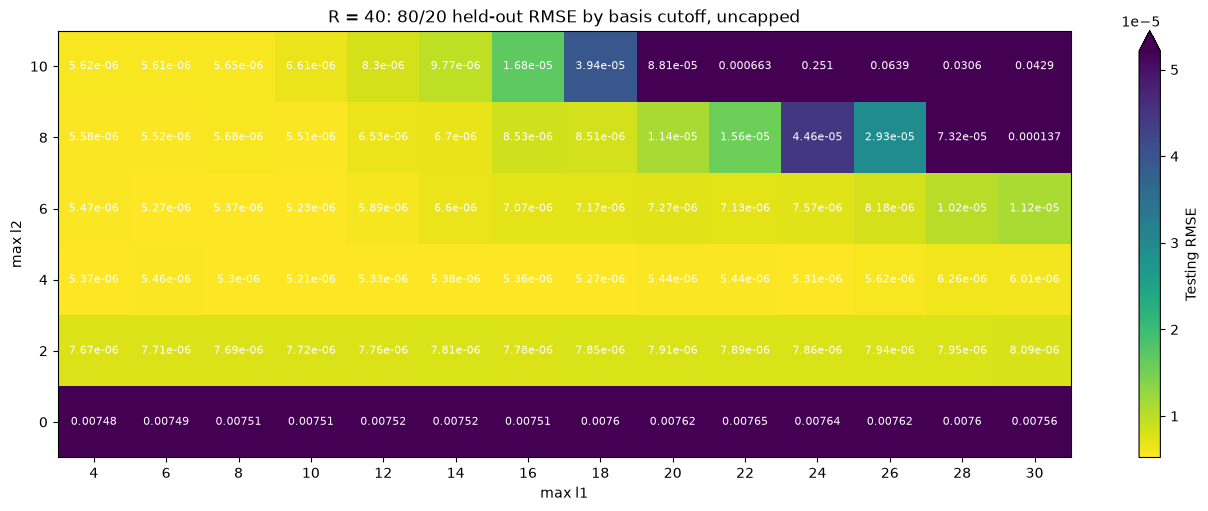

In [ ]:
all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
all_r_values = numpy.unique(all_data[:, 0])

# Use the same l1/l2 grid as above. Set this to None for the uncapped sweep.
all_r_terms_cap = None
all_r_train_fraction = train_fraction
all_r_random_seed = random_seed

all_r_sweep_results = {}

for r_value in all_r_values:
    r_data = all_data[all_data[:, 0] == r_value]
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=all_r_train_fraction,
        random_seed=all_r_random_seed,
    )

    r_sweep_result = run_basis_cutoff_sweep(
        r_training_data,
        r_testing_data,
        max_l1_grid,
        max_l2_grid,
        terms_cap=all_r_terms_cap,
    )
    all_r_sweep_results[float(r_value)] = r_sweep_result

    cap_label = "uncapped" if all_r_terms_cap is None else f"capped at {all_r_terms_cap} terms"
    plot_sweep_rmse_heatmap(
        r_sweep_result,
        title=f"R = {r_value:g}: 80/20 held-out RMSE by basis cutoff, {cap_label}",
    )
    print(f"R = {r_value:g}")
    print_sweep_best(r_sweep_result, label="R-slice")
    plt.show()


# Minimizing the number of terms

We use the following method to minimize the number of terms we need to use:

1. We perform the same sweep as before (for each value of $R$) but we *stop* once the testing relative RMSE is below a certain value (default 0.01) or we have performed the entire sweep. The sweep prioritizes the smallest total number of basis terms. Note that we should at least have l1 >= some value a and l2 >= some value of b for each value of R. (Default a = 8, b = 4). A maximum number of terms can be enforced with `terms_cap`; its default is `None`, which means no explicit cap beyond the l1/l2 cutoff.
2. We should save the basis $Q(R)$ and the coefficients for each value of R.
3. We then interpolate (between $R$s) as follows:

First define $Q_u \equiv \bigcup_{q} Q(R)$ (so that $Q_u$ contains all basis elements that were ever used). Then, define C_q(R) as the cubic smoothing spline of the shell-wise fitted coefficients *over the radii where the associated basis is active*. Finally, we have a function s_q(r) that forces certain terms to go to zero. In particular, we let

$$s_q(R) = \exp\{-a(R-R_{cutoff})^2\},$$

where $a$ is some parameter (set a reasonable default), and $R_{cutoff}$ is the largest value of $R$ for which that basis term appeared in the shell-wise fit. Note that if $R \leq R_{cutoff}$, then $s_q(R) = 1$. (The reason for the square is everywhere differentiability). 

The final PES is then of the form
$$V(R, \Omega) = \sum_{q } s_q(R) C_q(R) A_q(\Omega),$$

where the last term is the angular dependence. 




In [11]:
def basis_cutoff_candidates(max_l1_grid, max_l2_grid, min_l1=8, min_l2=4, terms_cap=None):
    """Return candidate bases ordered by smallest total number of terms first."""
    candidates = []
    seen_bases = set()

    for candidate_max_l1 in sorted(int(value) for value in max_l1_grid):
        for candidate_max_l2 in sorted(int(value) for value in max_l2_grid):
            if candidate_max_l1 < min_l1 or candidate_max_l2 < min_l2:
                continue

            all_candidate_terms = generate_all_terms(candidate_max_l1, candidate_max_l2)
            if terms_cap is None:
                candidate_terms = all_candidate_terms
            else:
                candidate_terms = all_candidate_terms[:int(terms_cap)]

            basis_key = tuple(candidate_terms)
            if basis_key in seen_bases:
                continue
            seen_bases.add(basis_key)

            candidates.append({
                "max_l1": candidate_max_l1,
                "max_l2": candidate_max_l2,
                "basis_terms": candidate_terms,
                "term_count": len(candidate_terms),
            })

    candidates.sort(key=lambda candidate: (
        candidate["term_count"],
        candidate["max_l1"] + candidate["max_l2"],
        candidate["max_l1"],
        candidate["max_l2"],
    ))
    return candidates


def select_minimal_basis_for_shell(
    r_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
):
    """Choose the first smallest-term basis with testing relative RMSE below cutoff."""
    r_value = float(r_data[0, 0])
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=train_fraction,
        random_seed=random_seed,
    )

    candidates = basis_cutoff_candidates(
        max_l1_grid,
        max_l2_grid,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
    )
    if not candidates:
        raise ValueError("No basis candidates satisfy the requested l1/l2 minima.")

    tried_results = []
    best_result = None
    chosen_result = None
    passed_cutoff = False

    for candidate in candidates:
        score = fit_and_score(r_training_data, r_testing_data, candidate["basis_terms"])
        score.update(candidate)
        tried_results.append(score)

        if best_result is None or score["test_relative_rmse"] < best_result["test_relative_rmse"]:
            best_result = score

        if numpy.isfinite(score["test_relative_rmse"]) and score["test_relative_rmse"] <= relative_rmse_cutoff:
            chosen_result = score
            passed_cutoff = True
            break

    if chosen_result is None:
        chosen_result = best_result

    final_fit_data = r_data if refit_on_all_data else r_training_data
    final_fit = fit_basis(final_fit_data, chosen_result["basis_terms"])
    coefficient_by_term = dict(zip(chosen_result["basis_terms"], final_fit["coefficients"]))

    return {
        "R": r_value,
        "basis_terms": chosen_result["basis_terms"],
        "coefficient_by_term": coefficient_by_term,
        "coefficients": final_fit["coefficients"],
        "final_fit": final_fit,
        "selection_result": chosen_result,
        "tried_results": tried_results,
        "passed_cutoff": passed_cutoff,
        "max_l1": chosen_result["max_l1"],
        "max_l2": chosen_result["max_l2"],
        "term_count": chosen_result["term_count"],
        "training_rank": chosen_result["rank"],
        "test_rmse": chosen_result["test_rmse"],
        "test_relative_rmse": chosen_result["test_relative_rmse"],
        "train_rmse": chosen_result["train_rmse"],
        "train_relative_rmse": chosen_result["train_relative_rmse"],
        "training_indices": r_training_indices,
        "testing_indices": r_testing_indices,
        "refit_on_all_data": refit_on_all_data,
    }


def select_minimal_bases_by_radius(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    verbose=True,
):
    shell_fits = {}

    for radius_index, r_value in enumerate(numpy.unique(all_data[:, 0])):
        r_data = all_data[all_data[:, 0] == r_value]
        shell_seed = None if random_seed is None else int(random_seed) + radius_index
        shell_fit = select_minimal_basis_for_shell(
            r_data,
            max_l1_grid,
            max_l2_grid,
            relative_rmse_cutoff=relative_rmse_cutoff,
            min_l1=min_l1,
            min_l2=min_l2,
            terms_cap=terms_cap,
            train_fraction=train_fraction,
            random_seed=shell_seed,
            refit_on_all_data=refit_on_all_data,
        )
        shell_fits[float(r_value)] = shell_fit

        if verbose:
            status = "passed" if shell_fit["passed_cutoff"] else "best available"
            print(
                f"R = {r_value:g}: {status}, "
                f"test relative RMSE = {shell_fit['test_relative_rmse']:.6g}, "
                f"terms = {shell_fit['term_count']}, "
                f"max_l1 = {shell_fit['max_l1']}, max_l2 = {shell_fit['max_l2']}"
            )

    return shell_fits


def _constant_coefficient_model(value):
    def coefficient_model(R):
        R_array = numpy.asarray(R, dtype=float)
        result = numpy.full_like(R_array, float(value), dtype=float)
        return float(result) if result.shape == () else result

    return coefficient_model


def build_radial_coefficient_models(shell_fits, spline_smoothing=0.0, max_spline_degree=3):
    radii = sorted(shell_fits)
    Q_union = sorted(
        {term for shell_fit in shell_fits.values() for term in shell_fit["basis_terms"]},
        key=lambda term: (sum(term), term[0], term[1], term[2]),
    )
    coefficient_models = {}

    for term in Q_union:
        active_radii = []
        active_coefficients = []

        for r_value in radii:
            coefficient = shell_fits[r_value]["coefficient_by_term"].get(term)
            if coefficient is not None:
                active_radii.append(float(r_value))
                active_coefficients.append(float(coefficient))

        active_radii = numpy.asarray(active_radii, dtype=float)
        active_coefficients = numpy.asarray(active_coefficients, dtype=float)

        if active_radii.size == 1:
            spline_degree = 0
            coefficient_model = _constant_coefficient_model(active_coefficients[0])
        else:
            # Default spline parameters are here: interpolating UnivariateSpline, s=0.0, ext=0.
            # The degree is lowered automatically when fewer than 4 active radii are available.
            spline_degree = min(int(max_spline_degree), active_radii.size - 1)
            coefficient_model = scipy.interpolate.UnivariateSpline(
                active_radii,
                active_coefficients,
                k=spline_degree,
                s=spline_smoothing,
                ext=0,
            )

        coefficient_models[term] = {
            "term": term,
            "radii": active_radii,
            "coefficients": active_coefficients,
            "coefficient_model": coefficient_model,
            "spline_degree": spline_degree,
            "R_cutoff": float(active_radii.max()),
        }

    return Q_union, coefficient_models


def radial_switch(R, R_cutoff, decay_a=1.0):
    R_array = numpy.asarray(R, dtype=float)
    switched = numpy.where(
        R_array <= R_cutoff,
        1.0,
        numpy.exp(-float(decay_a) * (R_array - R_cutoff) ** 2),
    )
    return float(switched) if switched.shape == () else switched


def evaluate_minimized_pes(model, R, theta1, theta2, phi, angles_in_degrees=True):
    """Evaluate V(R, Omega) for scalar R and scalar or array-valued angles."""
    if numpy.ndim(R) != 0:
        raise NotImplementedError("evaluate_minimized_pes currently expects scalar R.")

    theta1_values = numpy.asarray(theta1, dtype=float)
    theta2_values = numpy.asarray(theta2, dtype=float)
    phi_values = numpy.asarray(phi, dtype=float)
    if angles_in_degrees:
        theta1_values = numpy.deg2rad(theta1_values)
        theta2_values = numpy.deg2rad(theta2_values)
        phi_values = numpy.deg2rad(phi_values)

    value = numpy.zeros_like(theta1_values, dtype=float)
    for term in model["Q_union"]:
        L, l1, l2 = term
        coefficient_info = model["coefficient_models"][term]
        coefficient = float(coefficient_info["coefficient_model"](R))
        switch = radial_switch(R, coefficient_info["R_cutoff"], decay_a=model["decay_a"])
        value = value + switch * coefficient * angular_basis(L, l1, l2, theta1_values, theta2_values, phi_values)

    return float(value) if value.shape == () else value


def build_minimized_pes_model(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    spline_smoothing=0.0,
    max_spline_degree=3,
    decay_a=1.0,
    verbose=True,
):
    shell_fits = select_minimal_bases_by_radius(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=relative_rmse_cutoff,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=refit_on_all_data,
        verbose=verbose,
    )
    Q_union, coefficient_models = build_radial_coefficient_models(
        shell_fits,
        spline_smoothing=spline_smoothing,
        max_spline_degree=max_spline_degree,
    )

    return {
        "shell_fits": shell_fits,
        "Q_union": Q_union,
        "coefficient_models": coefficient_models,
        "relative_rmse_cutoff": relative_rmse_cutoff,
        "min_l1": min_l1,
        "min_l2": min_l2,
        "terms_cap": terms_cap,
        "train_fraction": train_fraction,
        "random_seed": random_seed,
        "refit_on_all_data": refit_on_all_data,
        "spline_smoothing": spline_smoothing,
        "max_spline_degree": max_spline_degree,
        "decay_a": decay_a,
    }


# Defaults for the minimized-term PES construction.
minimized_relative_rmse_cutoff = 0.01
minimized_min_l1 = 0
minimized_min_l2 = 0
minimized_terms_cap = None
minimized_decay_a = 1.0
minimized_spline_smoothing = 0.0
minimized_max_spline_degree = 3

# Set this to True when you want to run the full all-R construction.
build_minimized_pes_now = True

if build_minimized_pes_now:
    all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
    minimized_pes_model = build_minimized_pes_model(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=minimized_relative_rmse_cutoff,
        min_l1=minimized_min_l1,
        min_l2=minimized_min_l2,
        terms_cap=minimized_terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=True,
        spline_smoothing=minimized_spline_smoothing,
        max_spline_degree=minimized_max_spline_degree,
        decay_a=minimized_decay_a,
        verbose=True,
    )


R = 4.4: passed, test relative RMSE = 0.00633326, terms = 74, max_l1 = 10, max_l2 = 4
R = 4.6: passed, test relative RMSE = 0.00906646, terms = 59, max_l1 = 8, max_l2 = 4
R = 4.8: passed, test relative RMSE = 0.0072641, terms = 59, max_l1 = 8, max_l2 = 4
R = 5: passed, test relative RMSE = 0.00897161, terms = 26, max_l1 = 8, max_l2 = 2
R = 5.2: passed, test relative RMSE = 0.00705206, terms = 26, max_l1 = 8, max_l2 = 2
R = 5.4: passed, test relative RMSE = 0.00532694, terms = 26, max_l1 = 8, max_l2 = 2
R = 5.6: passed, test relative RMSE = 0.00466097, terms = 26, max_l1 = 8, max_l2 = 2
R = 5.8: passed, test relative RMSE = 0.00543242, terms = 26, max_l1 = 8, max_l2 = 2
R = 6: passed, test relative RMSE = 0.00449559, terms = 26, max_l1 = 8, max_l2 = 2
R = 6.2: passed, test relative RMSE = 0.00461, terms = 26, max_l1 = 8, max_l2 = 2
R = 6.4: passed, test relative RMSE = 0.00475832, terms = 26, max_l1 = 8, max_l2 = 2
R = 6.6: passed, test relative RMSE = 0.00501348, terms = 26, max_l1 = 8

## Issues and Fixes With the above sweep

### Issues

Rank deficiency and *massive* coefficient blow up. Even though actual energy values are at most $10^5$, some coefficients approach $10^{15}$, about a billion times larger than they should be. As a result, many energies values are computed via large terms cancelling out, meaning that these results are not stable and are likely not usable for the interpolated $R$. 


### Fixes

Rather than naive SVD, we should use a truncated version with a truncation threshold (default: 10^-8) --- i.e., we should use truncated SVD.

Rather than naively increasing l1 and l2, we should just attempt fits by increasing the number of terms by 1 each time (in the ordering which we have already defined), and choose the first with relative RMSE < 1\%. 



In [12]:
def truncated_svd_lstsq(X, y, svd_threshold=1e-8, threshold_mode="relative"):
    """Solve least squares by discarding singular values below the threshold."""
    U, singular_values, Vh = scipy.linalg.svd(X, full_matrices=False, check_finite=False)

    if singular_values.size == 0:
        return numpy.zeros(X.shape[1]), 0, singular_values, 0.0

    if threshold_mode == "relative":
        cutoff = float(svd_threshold) * float(singular_values[0])
    elif threshold_mode == "absolute":
        cutoff = float(svd_threshold)
    else:
        raise ValueError("threshold_mode must be 'relative' or 'absolute'.")

    retained = singular_values > cutoff
    rank = int(numpy.count_nonzero(retained))
    if rank == 0:
        return numpy.zeros(X.shape[1]), rank, singular_values, cutoff

    coefficients = Vh[retained, :].T @ ((U[:, retained].T @ y) / singular_values[retained])
    return coefficients, rank, singular_values, cutoff


def fit_basis_truncated_svd(data_subset, basis_terms, svd_threshold=1e-8, threshold_mode="relative"):
    X_fit = design_matrix_for(data_subset, basis_terms)
    y_fit = data_subset[:, 4]
    coefficients_fit, rank_fit, singular_values_fit, svd_cutoff = truncated_svd_lstsq(
        X_fit,
        y_fit,
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
    )
    fitted_values = X_fit @ coefficients_fit
    residuals = y_fit - fitted_values

    if rank_fit > 0:
        retained_singular_values = singular_values_fit[singular_values_fit > svd_cutoff]
        retained_condition_number = float(retained_singular_values[0] / retained_singular_values[-1])
    else:
        retained_condition_number = numpy.inf

    full_condition_number = numpy.inf
    if singular_values_fit.size > 0 and singular_values_fit[-1] > 0:
        full_condition_number = float(singular_values_fit[0] / singular_values_fit[-1])

    return {
        "basis_terms": basis_terms,
        "X": X_fit,
        "V": y_fit,
        "coefficients": coefficients_fit,
        "rank": rank_fit,
        "singular_values": singular_values_fit,
        "svd_threshold": svd_threshold,
        "threshold_mode": threshold_mode,
        "svd_cutoff": svd_cutoff,
        "discarded_singular_count": int(singular_values_fit.size - rank_fit),
        "retained_condition_number": retained_condition_number,
        "full_condition_number": full_condition_number,
        "fit_values": fitted_values,
        "fit_residuals": residuals,
        "sse": float(numpy.sum(residuals**2)),
        "rmse": float(numpy.sqrt(numpy.mean(residuals**2))),
        "relative_rmse": relative_rmse(residuals, y_fit),
        "max_abs_error": float(numpy.max(numpy.abs(residuals))),
        "max_abs_coefficient": float(numpy.max(numpy.abs(coefficients_fit))) if coefficients_fit.size else 0.0,
        "coefficient_l2_norm": float(numpy.linalg.norm(coefficients_fit)),
    }


def fit_and_score_truncated_svd(
    train_subset,
    test_subset,
    basis_terms,
    svd_threshold=1e-8,
    threshold_mode="relative",
):
    train_fit = fit_basis_truncated_svd(
        train_subset,
        basis_terms,
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
    )
    X_test = design_matrix_for(test_subset, basis_terms)
    y_test = test_subset[:, 4]
    test_residuals = y_test - X_test @ train_fit["coefficients"]

    return {
        "test_rmse": float(numpy.sqrt(numpy.mean(test_residuals**2))),
        "test_relative_rmse": relative_rmse(test_residuals, y_test),
        "train_rmse": train_fit["rmse"],
        "train_relative_rmse": train_fit["relative_rmse"],
        "term_count": len(basis_terms),
        "rank": int(train_fit["rank"]),
        "discarded_singular_count": train_fit["discarded_singular_count"],
        "svd_cutoff": train_fit["svd_cutoff"],
        "retained_condition_number": train_fit["retained_condition_number"],
        "full_condition_number": train_fit["full_condition_number"],
        "max_abs_coefficient": train_fit["max_abs_coefficient"],
        "coefficient_l2_norm": train_fit["coefficient_l2_norm"],
        "basis_terms": basis_terms,
        "coefficients": train_fit["coefficients"],
        "test_residuals": test_residuals,
    }


def basis_support_cutoffs(basis_terms):
    if not basis_terms:
        return {"max_l1": 0, "max_l2": 0, "max_L": 0}
    return {
        "max_L": max(term[0] for term in basis_terms),
        "max_l1": max(term[1] for term in basis_terms),
        "max_l2": max(term[2] for term in basis_terms),
    }


def incremental_term_candidates(universe_max_l1, universe_max_l2, min_terms=1, max_terms=None):
    ordered_terms = generate_all_terms(universe_max_l1, universe_max_l2)
    if max_terms is None:
        max_terms = len(ordered_terms)
    max_terms = min(int(max_terms), len(ordered_terms))
    min_terms = max(1, int(min_terms))

    if min_terms > max_terms:
        raise ValueError("min_terms cannot be larger than max_terms.")

    for term_count in range(min_terms, max_terms + 1):
        basis_terms = ordered_terms[:term_count]
        yield {
            "basis_terms": basis_terms,
            "term_count": term_count,
            **basis_support_cutoffs(basis_terms),
        }


def select_incremental_terms_for_shell_truncated_svd(
    r_data,
    universe_max_l1,
    universe_max_l2,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_terms=1,
    max_terms=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
):
    r_value = float(r_data[0, 0])
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=train_fraction,
        random_seed=random_seed,
    )

    tried_results = []
    best_result = None
    chosen_result = None
    passed_cutoff = False

    for candidate in incremental_term_candidates(
        universe_max_l1,
        universe_max_l2,
        min_terms=min_terms,
        max_terms=max_terms,
    ):
        score = fit_and_score_truncated_svd(
            r_training_data,
            r_testing_data,
            candidate["basis_terms"],
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
        )
        score.update(candidate)
        tried_results.append(score)

        if best_result is None or score["test_relative_rmse"] < best_result["test_relative_rmse"]:
            best_result = score

        if numpy.isfinite(score["test_relative_rmse"]) and score["test_relative_rmse"] <= relative_rmse_cutoff:
            chosen_result = score
            passed_cutoff = True
            break

    if chosen_result is None:
        chosen_result = best_result

    final_fit_data = r_data if refit_on_all_data else r_training_data
    final_fit = fit_basis_truncated_svd(
        final_fit_data,
        chosen_result["basis_terms"],
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
    )
    coefficient_by_term = dict(zip(chosen_result["basis_terms"], final_fit["coefficients"]))

    return {
        "R": r_value,
        "basis_terms": chosen_result["basis_terms"],
        "coefficient_by_term": coefficient_by_term,
        "coefficients": final_fit["coefficients"],
        "final_fit": final_fit,
        "selection_result": chosen_result,
        "tried_results": tried_results,
        "passed_cutoff": passed_cutoff,
        "term_count": chosen_result["term_count"],
        "max_L": chosen_result["max_L"],
        "max_l1": chosen_result["max_l1"],
        "max_l2": chosen_result["max_l2"],
        "training_rank": chosen_result["rank"],
        "discarded_singular_count": chosen_result["discarded_singular_count"],
        "svd_cutoff": chosen_result["svd_cutoff"],
        "retained_condition_number": chosen_result["retained_condition_number"],
        "full_condition_number": chosen_result["full_condition_number"],
        "max_abs_coefficient": final_fit["max_abs_coefficient"],
        "coefficient_l2_norm": final_fit["coefficient_l2_norm"],
        "test_rmse": chosen_result["test_rmse"],
        "test_relative_rmse": chosen_result["test_relative_rmse"],
        "train_rmse": chosen_result["train_rmse"],
        "train_relative_rmse": chosen_result["train_relative_rmse"],
        "training_indices": r_training_indices,
        "testing_indices": r_testing_indices,
        "refit_on_all_data": refit_on_all_data,
    }


def select_incremental_terms_by_radius_truncated_svd(
    all_data,
    universe_max_l1,
    universe_max_l2,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_terms=1,
    max_terms=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    verbose=True,
):
    shell_fits = {}

    for radius_index, r_value in enumerate(numpy.unique(all_data[:, 0])):
        r_data = all_data[all_data[:, 0] == r_value]
        shell_seed = None if random_seed is None else int(random_seed) + radius_index
        shell_fit = select_incremental_terms_for_shell_truncated_svd(
            r_data,
            universe_max_l1,
            universe_max_l2,
            relative_rmse_cutoff=relative_rmse_cutoff,
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
            min_terms=min_terms,
            max_terms=max_terms,
            train_fraction=train_fraction,
            random_seed=shell_seed,
            refit_on_all_data=refit_on_all_data,
        )
        shell_fits[float(r_value)] = shell_fit

        if verbose:
            status = "passed" if shell_fit["passed_cutoff"] else "best available"
            print(
                f"R = {r_value:g}: {status}, "
                f"test relative RMSE = {shell_fit['test_relative_rmse']:.6g}, "
                f"terms = {shell_fit['term_count']}, "
                f"rank = {shell_fit['training_rank']}, "
                f"discarded singular values = {shell_fit['discarded_singular_count']}, "
                f"max abs coefficient = {shell_fit['max_abs_coefficient']:.6g}"
            )

    return shell_fits


def build_incremental_truncated_svd_pes_model(
    all_data,
    universe_max_l1,
    universe_max_l2,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_terms=1,
    max_terms=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    spline_smoothing=0.0,
    max_spline_degree=3,
    decay_a=1.0,
    verbose=True,
):
    shell_fits = select_incremental_terms_by_radius_truncated_svd(
        all_data,
        universe_max_l1,
        universe_max_l2,
        relative_rmse_cutoff=relative_rmse_cutoff,
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
        min_terms=min_terms,
        max_terms=max_terms,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=refit_on_all_data,
        verbose=verbose,
    )
    Q_union, coefficient_models = build_radial_coefficient_models(
        shell_fits,
        spline_smoothing=spline_smoothing,
        max_spline_degree=max_spline_degree,
    )

    return {
        "shell_fits": shell_fits,
        "Q_union": Q_union,
        "coefficient_models": coefficient_models,
        "relative_rmse_cutoff": relative_rmse_cutoff,
        "svd_threshold": svd_threshold,
        "threshold_mode": threshold_mode,
        "universe_max_l1": universe_max_l1,
        "universe_max_l2": universe_max_l2,
        "min_terms": min_terms,
        "max_terms": max_terms,
        "train_fraction": train_fraction,
        "random_seed": random_seed,
        "refit_on_all_data": refit_on_all_data,
        "spline_smoothing": spline_smoothing,
        "max_spline_degree": max_spline_degree,
        "decay_a": decay_a,
    }


# Defaults for the truncated-SVD, incremental-term workflow.
incremental_relative_rmse_cutoff = 0.01
incremental_svd_threshold = 1e-8
incremental_threshold_mode = "relative"
incremental_universe_max_l1 = max(max_l1_grid) if "max_l1_grid" in globals() else max_l1
incremental_universe_max_l2 = max(max_l2_grid) if "max_l2_grid" in globals() else max_l2
incremental_min_terms = 1
incremental_max_terms = None
build_incremental_truncated_svd_pes_now = True

if build_incremental_truncated_svd_pes_now:
    all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
    incremental_truncated_svd_pes_model = build_incremental_truncated_svd_pes_model(
        all_data,
        incremental_universe_max_l1,
        incremental_universe_max_l2,
        relative_rmse_cutoff=incremental_relative_rmse_cutoff,
        svd_threshold=incremental_svd_threshold,
        threshold_mode=incremental_threshold_mode,
        min_terms=incremental_min_terms,
        max_terms=incremental_max_terms,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=True,
        spline_smoothing=minimized_spline_smoothing,
        max_spline_degree=minimized_max_spline_degree,
        decay_a=minimized_decay_a,
        verbose=True,
    )


R = 4.4: passed, test relative RMSE = 0.00887315, terms = 116, rank = 88, discarded singular values = 28, max abs coefficient = 88778.7
R = 4.6: passed, test relative RMSE = 0.00959753, terms = 85, rank = 67, discarded singular values = 18, max abs coefficient = 1.56115e+06
R = 4.8: passed, test relative RMSE = 0.00969732, terms = 75, rank = 59, discarded singular values = 16, max abs coefficient = 43606.2
R = 5: passed, test relative RMSE = 0.00997089, terms = 70, rank = 56, discarded singular values = 14, max abs coefficient = 55003.1
R = 5.2: passed, test relative RMSE = 0.00784201, terms = 65, rank = 51, discarded singular values = 14, max abs coefficient = 22364.5
R = 5.4: passed, test relative RMSE = 0.00811813, terms = 65, rank = 51, discarded singular values = 14, max abs coefficient = 15732.4
R = 5.6: passed, test relative RMSE = 0.00620506, terms = 65, rank = 51, discarded singular values = 14, max abs coefficient = 10938.4
R = 5.8: passed, test relative RMSE = 0.00773896, te

In [13]:
def select_minimal_basis_for_shell_truncated_svd(
    r_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
):
    """Choose a max-l1/max-l2 basis using truncated-SVD least squares."""
    r_value = float(r_data[0, 0])
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=train_fraction,
        random_seed=random_seed,
    )

    candidates = basis_cutoff_candidates(
        max_l1_grid,
        max_l2_grid,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
    )
    if not candidates:
        raise ValueError("No basis candidates satisfy the requested l1/l2 minima.")

    tried_results = []
    best_result = None
    chosen_result = None
    passed_cutoff = False

    for candidate in candidates:
        score = fit_and_score_truncated_svd(
            r_training_data,
            r_testing_data,
            candidate["basis_terms"],
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
        )
        score.update(candidate)
        tried_results.append(score)

        if best_result is None or score["test_relative_rmse"] < best_result["test_relative_rmse"]:
            best_result = score

        if numpy.isfinite(score["test_relative_rmse"]) and score["test_relative_rmse"] <= relative_rmse_cutoff:
            chosen_result = score
            passed_cutoff = True
            break

    if chosen_result is None:
        chosen_result = best_result

    final_fit_data = r_data if refit_on_all_data else r_training_data
    final_fit = fit_basis_truncated_svd(
        final_fit_data,
        chosen_result["basis_terms"],
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
    )
    coefficient_by_term = dict(zip(chosen_result["basis_terms"], final_fit["coefficients"]))

    return {
        "R": r_value,
        "basis_terms": chosen_result["basis_terms"],
        "coefficient_by_term": coefficient_by_term,
        "coefficients": final_fit["coefficients"],
        "final_fit": final_fit,
        "selection_result": chosen_result,
        "tried_results": tried_results,
        "passed_cutoff": passed_cutoff,
        "max_l1": chosen_result["max_l1"],
        "max_l2": chosen_result["max_l2"],
        "term_count": chosen_result["term_count"],
        "training_rank": chosen_result["rank"],
        "discarded_singular_count": chosen_result["discarded_singular_count"],
        "svd_cutoff": chosen_result["svd_cutoff"],
        "retained_condition_number": chosen_result["retained_condition_number"],
        "full_condition_number": chosen_result["full_condition_number"],
        "max_abs_coefficient": final_fit["max_abs_coefficient"],
        "coefficient_l2_norm": final_fit["coefficient_l2_norm"],
        "test_rmse": chosen_result["test_rmse"],
        "test_relative_rmse": chosen_result["test_relative_rmse"],
        "train_rmse": chosen_result["train_rmse"],
        "train_relative_rmse": chosen_result["train_relative_rmse"],
        "training_indices": r_training_indices,
        "testing_indices": r_testing_indices,
        "refit_on_all_data": refit_on_all_data,
    }


def select_minimal_bases_by_radius_truncated_svd(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    verbose=True,
):
    shell_fits = {}

    for radius_index, r_value in enumerate(numpy.unique(all_data[:, 0])):
        r_data = all_data[all_data[:, 0] == r_value]
        shell_seed = None if random_seed is None else int(random_seed) + radius_index
        shell_fit = select_minimal_basis_for_shell_truncated_svd(
            r_data,
            max_l1_grid,
            max_l2_grid,
            relative_rmse_cutoff=relative_rmse_cutoff,
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
            min_l1=min_l1,
            min_l2=min_l2,
            terms_cap=terms_cap,
            train_fraction=train_fraction,
            random_seed=shell_seed,
            refit_on_all_data=refit_on_all_data,
        )
        shell_fits[float(r_value)] = shell_fit

        if verbose:
            status = "passed" if shell_fit["passed_cutoff"] else "best available"
            print(
                f"R = {r_value:g}: {status}, "
                f"test relative RMSE = {shell_fit['test_relative_rmse']:.6g}, "
                f"terms = {shell_fit['term_count']}, "
                f"max_l1 = {shell_fit['max_l1']}, max_l2 = {shell_fit['max_l2']}, "
                f"rank = {shell_fit['training_rank']}, "
                f"discarded singular values = {shell_fit['discarded_singular_count']}, "
                f"max abs coefficient = {shell_fit['max_abs_coefficient']:.6g}"
            )

    return shell_fits


def build_minimized_truncated_svd_pes_model(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    spline_smoothing=0.0,
    max_spline_degree=3,
    decay_a=1.0,
    verbose=True,
):
    shell_fits = select_minimal_bases_by_radius_truncated_svd(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=relative_rmse_cutoff,
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=refit_on_all_data,
        verbose=verbose,
    )
    Q_union, coefficient_models = build_radial_coefficient_models(
        shell_fits,
        spline_smoothing=spline_smoothing,
        max_spline_degree=max_spline_degree,
    )

    return {
        "shell_fits": shell_fits,
        "Q_union": Q_union,
        "coefficient_models": coefficient_models,
        "relative_rmse_cutoff": relative_rmse_cutoff,
        "svd_threshold": svd_threshold,
        "threshold_mode": threshold_mode,
        "min_l1": min_l1,
        "min_l2": min_l2,
        "terms_cap": terms_cap,
        "train_fraction": train_fraction,
        "random_seed": random_seed,
        "refit_on_all_data": refit_on_all_data,
        "spline_smoothing": spline_smoothing,
        "max_spline_degree": max_spline_degree,
        "decay_a": decay_a,
    }


# Defaults for the max-l1/max-l2 sweep with truncated-SVD least squares.
minimized_truncated_svd_relative_rmse_cutoff = 0.01
minimized_truncated_svd_threshold = 1e-8
minimized_truncated_svd_threshold_mode = "relative"
minimized_truncated_svd_min_l1 = minimized_min_l1 if "minimized_min_l1" in globals() else 0
minimized_truncated_svd_min_l2 = minimized_min_l2 if "minimized_min_l2" in globals() else 0
minimized_truncated_svd_terms_cap = minimized_terms_cap if "minimized_terms_cap" in globals() else None
build_minimized_truncated_svd_pes_now = True

if build_minimized_truncated_svd_pes_now:
    all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
    minimized_truncated_svd_pes_model = build_minimized_truncated_svd_pes_model(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=minimized_truncated_svd_relative_rmse_cutoff,
        svd_threshold=minimized_truncated_svd_threshold,
        threshold_mode=minimized_truncated_svd_threshold_mode,
        min_l1=minimized_truncated_svd_min_l1,
        min_l2=minimized_truncated_svd_min_l2,
        terms_cap=minimized_truncated_svd_terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=True,
        spline_smoothing=minimized_spline_smoothing,
        max_spline_degree=minimized_max_spline_degree,
        decay_a=minimized_decay_a,
        verbose=True,
    )


R = 4.4: passed, test relative RMSE = 0.00633421, terms = 74, max_l1 = 10, max_l2 = 4, rank = 46, discarded singular values = 28, max abs coefficient = 80823.7
R = 4.6: passed, test relative RMSE = 0.00906742, terms = 59, max_l1 = 8, max_l2 = 4, rank = 37, discarded singular values = 22, max abs coefficient = 59777.5
R = 4.8: passed, test relative RMSE = 0.00726403, terms = 59, max_l1 = 8, max_l2 = 4, rank = 37, discarded singular values = 22, max abs coefficient = 43606.9
R = 5: passed, test relative RMSE = 0.00897161, terms = 26, max_l1 = 8, max_l2 = 2, rank = 18, discarded singular values = 8, max abs coefficient = 31392.3
R = 5.2: passed, test relative RMSE = 0.00705206, terms = 26, max_l1 = 8, max_l2 = 2, rank = 18, discarded singular values = 8, max abs coefficient = 22345.2
R = 5.4: passed, test relative RMSE = 0.00532694, terms = 26, max_l1 = 8, max_l2 = 2, rank = 18, discarded singular values = 8, max abs coefficient = 15720.1
R = 5.6: passed, test relative RMSE = 0.00466097, 

### Truncated-SVD sweep with hysteresis

This repeats the max-`l1`/max-`l2` truncated-SVD selection while carrying the previous three radii into the next shell.
If those three selected cutoffs are equal or nonincreasing in both coordinates, the oldest/largest cutoff becomes the hysteresis anchor.
Candidates at or above that anchor may pass with a 30% relaxed relative-RMSE cutoff; all other candidates use the original cutoff.


In [14]:
def hysteresis_anchor_from_previous_shells(previous_shell_fits, required_previous_count=3):
    """Return the oldest/largest cutoff when the previous selected cutoffs are nonincreasing."""
    if len(previous_shell_fits) < required_previous_count:
        return None

    previous_shells = list(previous_shell_fits[-required_previous_count:])
    max_l1_values = [int(shell_fit["max_l1"]) for shell_fit in previous_shells]
    max_l2_values = [int(shell_fit["max_l2"]) for shell_fit in previous_shells]

    max_l1_nonincreasing = all(
        max_l1_values[index] >= max_l1_values[index + 1]
        for index in range(len(max_l1_values) - 1)
    )
    max_l2_nonincreasing = all(
        max_l2_values[index] >= max_l2_values[index + 1]
        for index in range(len(max_l2_values) - 1)
    )
    if not (max_l1_nonincreasing and max_l2_nonincreasing):
        return None

    anchor_shell = previous_shells[0]
    return {
        "max_l1": int(anchor_shell["max_l1"]),
        "max_l2": int(anchor_shell["max_l2"]),
        "source_radii": [float(shell_fit["R"]) for shell_fit in previous_shells],
        "source_max_l1_values": max_l1_values,
        "source_max_l2_values": max_l2_values,
    }


def candidate_receives_hysteresis_tolerance(candidate, hysteresis_anchor):
    if hysteresis_anchor is None:
        return False
    return (
        int(candidate["max_l1"]) >= int(hysteresis_anchor["max_l1"])
        and int(candidate["max_l2"]) >= int(hysteresis_anchor["max_l2"])
    )


def select_minimal_basis_for_shell_truncated_svd_with_hysteresis(
    r_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    hysteresis_anchor=None,
    hysteresis_relative_tolerance=0.30,
):
    """Choose a max-l1/max-l2 basis, with optional hysteresis on the RMSE cutoff."""
    r_value = float(r_data[0, 0])
    r_training_data, r_testing_data, r_training_indices, r_testing_indices = create_train_test_split(
        r_data,
        train_fraction=train_fraction,
        random_seed=random_seed,
    )

    candidates = basis_cutoff_candidates(
        max_l1_grid,
        max_l2_grid,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
    )
    if not candidates:
        raise ValueError("No basis candidates satisfy the requested l1/l2 minima.")

    tried_results = []
    best_result = None
    chosen_result = None
    passed_cutoff = False
    passed_base_cutoff = False

    for candidate in candidates:
        score = fit_and_score_truncated_svd(
            r_training_data,
            r_testing_data,
            candidate["basis_terms"],
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
        )
        score.update(candidate)

        hysteresis_eligible = candidate_receives_hysteresis_tolerance(candidate, hysteresis_anchor)
        active_relative_rmse_cutoff = float(relative_rmse_cutoff)
        if hysteresis_eligible:
            active_relative_rmse_cutoff *= 1.0 + float(hysteresis_relative_tolerance)

        score["hysteresis_eligible"] = hysteresis_eligible
        score["active_relative_rmse_cutoff"] = active_relative_rmse_cutoff
        score["passes_base_cutoff"] = bool(
            numpy.isfinite(score["test_relative_rmse"])
            and score["test_relative_rmse"] <= relative_rmse_cutoff
        )
        score["passes_active_cutoff"] = bool(
            numpy.isfinite(score["test_relative_rmse"])
            and score["test_relative_rmse"] <= active_relative_rmse_cutoff
        )
        tried_results.append(score)

        if best_result is None or score["test_relative_rmse"] < best_result["test_relative_rmse"]:
            best_result = score

        if score["passes_active_cutoff"]:
            chosen_result = score
            passed_cutoff = True
            passed_base_cutoff = score["passes_base_cutoff"]
            break

    if chosen_result is None:
        chosen_result = best_result

    used_hysteresis = bool(
        chosen_result.get("hysteresis_eligible", False)
        and chosen_result.get("passes_active_cutoff", False)
        and not chosen_result.get("passes_base_cutoff", False)
    )

    final_fit_data = r_data if refit_on_all_data else r_training_data
    final_fit = fit_basis_truncated_svd(
        final_fit_data,
        chosen_result["basis_terms"],
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
    )
    coefficient_by_term = dict(zip(chosen_result["basis_terms"], final_fit["coefficients"]))

    return {
        "R": r_value,
        "basis_terms": chosen_result["basis_terms"],
        "coefficient_by_term": coefficient_by_term,
        "coefficients": final_fit["coefficients"],
        "final_fit": final_fit,
        "selection_result": chosen_result,
        "tried_results": tried_results,
        "passed_cutoff": passed_cutoff,
        "passed_base_cutoff": passed_base_cutoff,
        "used_hysteresis": used_hysteresis,
        "hysteresis_anchor": hysteresis_anchor,
        "hysteresis_relative_tolerance": hysteresis_relative_tolerance,
        "active_relative_rmse_cutoff": chosen_result.get("active_relative_rmse_cutoff", relative_rmse_cutoff),
        "max_l1": chosen_result["max_l1"],
        "max_l2": chosen_result["max_l2"],
        "term_count": chosen_result["term_count"],
        "training_rank": chosen_result["rank"],
        "discarded_singular_count": chosen_result["discarded_singular_count"],
        "svd_cutoff": chosen_result["svd_cutoff"],
        "retained_condition_number": chosen_result["retained_condition_number"],
        "full_condition_number": chosen_result["full_condition_number"],
        "max_abs_coefficient": final_fit["max_abs_coefficient"],
        "coefficient_l2_norm": final_fit["coefficient_l2_norm"],
        "test_rmse": chosen_result["test_rmse"],
        "test_relative_rmse": chosen_result["test_relative_rmse"],
        "train_rmse": chosen_result["train_rmse"],
        "train_relative_rmse": chosen_result["train_relative_rmse"],
        "training_indices": r_training_indices,
        "testing_indices": r_testing_indices,
        "refit_on_all_data": refit_on_all_data,
    }


def select_minimal_bases_by_radius_truncated_svd_with_hysteresis(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    hysteresis_previous_count=3,
    hysteresis_relative_tolerance=0.30,
    verbose=True,
):
    shell_fits = {}
    previous_shell_fits = []

    for radius_index, r_value in enumerate(numpy.unique(all_data[:, 0])):
        r_data = all_data[all_data[:, 0] == r_value]
        shell_seed = None if random_seed is None else int(random_seed) + radius_index
        hysteresis_anchor = hysteresis_anchor_from_previous_shells(
            previous_shell_fits,
            required_previous_count=hysteresis_previous_count,
        )
        shell_fit = select_minimal_basis_for_shell_truncated_svd_with_hysteresis(
            r_data,
            max_l1_grid,
            max_l2_grid,
            relative_rmse_cutoff=relative_rmse_cutoff,
            svd_threshold=svd_threshold,
            threshold_mode=threshold_mode,
            min_l1=min_l1,
            min_l2=min_l2,
            terms_cap=terms_cap,
            train_fraction=train_fraction,
            random_seed=shell_seed,
            refit_on_all_data=refit_on_all_data,
            hysteresis_anchor=hysteresis_anchor,
            hysteresis_relative_tolerance=hysteresis_relative_tolerance,
        )
        shell_fits[float(r_value)] = shell_fit
        previous_shell_fits.append(shell_fit)

        if verbose:
            if shell_fit["used_hysteresis"]:
                status = "hysteresis passed"
            elif shell_fit["passed_base_cutoff"]:
                status = "passed"
            else:
                status = "best available"
            print(
                f"R = {r_value:g}: {status}, "
                f"test relative RMSE = {shell_fit['test_relative_rmse']:.6g}, "
                f"active cutoff = {shell_fit['active_relative_rmse_cutoff']:.6g}, "
                f"terms = {shell_fit['term_count']}, "
                f"max_l1 = {shell_fit['max_l1']}, max_l2 = {shell_fit['max_l2']}, "
                f"rank = {shell_fit['training_rank']}, "
                f"discarded singular values = {shell_fit['discarded_singular_count']}, "
                f"max abs coefficient = {shell_fit['max_abs_coefficient']:.6g}"
            )

    return shell_fits


def build_minimized_truncated_svd_hysteresis_pes_model(
    all_data,
    max_l1_grid,
    max_l2_grid,
    relative_rmse_cutoff=0.01,
    svd_threshold=1e-8,
    threshold_mode="relative",
    min_l1=8,
    min_l2=4,
    terms_cap=None,
    train_fraction=0.80,
    random_seed=202605702,
    refit_on_all_data=True,
    hysteresis_previous_count=3,
    hysteresis_relative_tolerance=0.30,
    spline_smoothing=0.0,
    max_spline_degree=3,
    decay_a=1.0,
    verbose=True,
):
    shell_fits = select_minimal_bases_by_radius_truncated_svd_with_hysteresis(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=relative_rmse_cutoff,
        svd_threshold=svd_threshold,
        threshold_mode=threshold_mode,
        min_l1=min_l1,
        min_l2=min_l2,
        terms_cap=terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=refit_on_all_data,
        hysteresis_previous_count=hysteresis_previous_count,
        hysteresis_relative_tolerance=hysteresis_relative_tolerance,
        verbose=verbose,
    )
    Q_union, coefficient_models = build_radial_coefficient_models(
        shell_fits,
        spline_smoothing=spline_smoothing,
        max_spline_degree=max_spline_degree,
    )

    return {
        "shell_fits": shell_fits,
        "Q_union": Q_union,
        "coefficient_models": coefficient_models,
        "relative_rmse_cutoff": relative_rmse_cutoff,
        "svd_threshold": svd_threshold,
        "threshold_mode": threshold_mode,
        "min_l1": min_l1,
        "min_l2": min_l2,
        "terms_cap": terms_cap,
        "train_fraction": train_fraction,
        "random_seed": random_seed,
        "refit_on_all_data": refit_on_all_data,
        "hysteresis_previous_count": hysteresis_previous_count,
        "hysteresis_relative_tolerance": hysteresis_relative_tolerance,
        "spline_smoothing": spline_smoothing,
        "max_spline_degree": max_spline_degree,
        "decay_a": decay_a,
    }


# Defaults for the max-l1/max-l2 truncated-SVD sweep with hysteresis.
minimized_truncated_svd_hysteresis_relative_rmse_cutoff = 0.01
minimized_truncated_svd_hysteresis_threshold = 1e-8
minimized_truncated_svd_hysteresis_threshold_mode = "relative"
minimized_truncated_svd_hysteresis_min_l1 = minimized_min_l1 if "minimized_min_l1" in globals() else 0
minimized_truncated_svd_hysteresis_min_l2 = minimized_min_l2 if "minimized_min_l2" in globals() else 0
minimized_truncated_svd_hysteresis_terms_cap = minimized_terms_cap if "minimized_terms_cap" in globals() else None
minimized_truncated_svd_hysteresis_previous_count = 3
minimized_truncated_svd_hysteresis_relative_tolerance = 0.30
build_minimized_truncated_svd_hysteresis_pes_now = True

if build_minimized_truncated_svd_hysteresis_pes_now:
    all_data = numpy.loadtxt("data/all_avcbs_uniform.dat")
    minimized_truncated_svd_hysteresis_pes_model = build_minimized_truncated_svd_hysteresis_pes_model(
        all_data,
        max_l1_grid,
        max_l2_grid,
        relative_rmse_cutoff=minimized_truncated_svd_hysteresis_relative_rmse_cutoff,
        svd_threshold=minimized_truncated_svd_hysteresis_threshold,
        threshold_mode=minimized_truncated_svd_hysteresis_threshold_mode,
        min_l1=minimized_truncated_svd_hysteresis_min_l1,
        min_l2=minimized_truncated_svd_hysteresis_min_l2,
        terms_cap=minimized_truncated_svd_hysteresis_terms_cap,
        train_fraction=train_fraction,
        random_seed=random_seed,
        refit_on_all_data=True,
        hysteresis_previous_count=minimized_truncated_svd_hysteresis_previous_count,
        hysteresis_relative_tolerance=minimized_truncated_svd_hysteresis_relative_tolerance,
        spline_smoothing=minimized_spline_smoothing,
        max_spline_degree=minimized_max_spline_degree,
        decay_a=minimized_decay_a,
        verbose=True,
    )


R = 4.4: passed, test relative RMSE = 0.00633421, active cutoff = 0.01, terms = 74, max_l1 = 10, max_l2 = 4, rank = 46, discarded singular values = 28, max abs coefficient = 80823.7
R = 4.6: passed, test relative RMSE = 0.00906742, active cutoff = 0.01, terms = 59, max_l1 = 8, max_l2 = 4, rank = 37, discarded singular values = 22, max abs coefficient = 59777.5
R = 4.8: passed, test relative RMSE = 0.00726403, active cutoff = 0.01, terms = 59, max_l1 = 8, max_l2 = 4, rank = 37, discarded singular values = 22, max abs coefficient = 43606.9
R = 5: passed, test relative RMSE = 0.00897161, active cutoff = 0.01, terms = 26, max_l1 = 8, max_l2 = 2, rank = 18, discarded singular values = 8, max abs coefficient = 31392.3
R = 5.2: passed, test relative RMSE = 0.00705206, active cutoff = 0.01, terms = 26, max_l1 = 8, max_l2 = 2, rank = 18, discarded singular values = 8, max abs coefficient = 22345.2
R = 5.4: passed, test relative RMSE = 0.00532694, active cutoff = 0.01, terms = 26, max_l1 = 8, ma

Using model: minimized_truncated_svd_hysteresis_pes_model


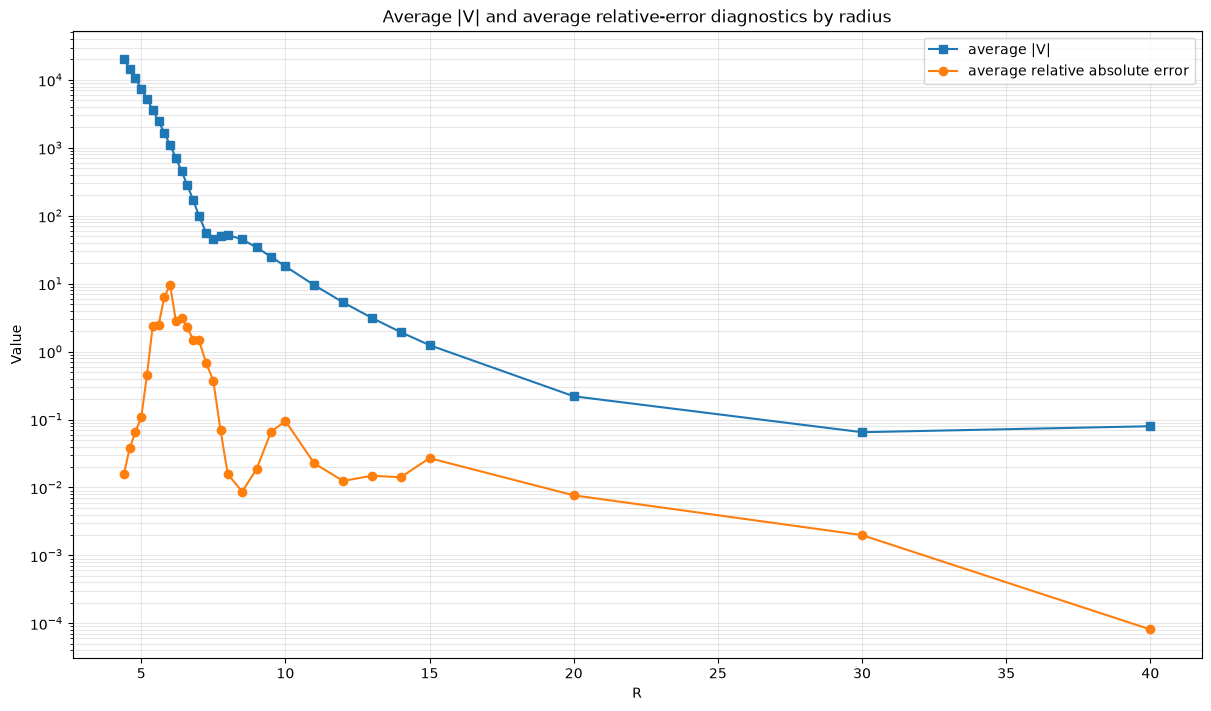

Brief comparison: relative to the simpler CO2-He fit, this more complex CO2-H fit has a largest average relative absolute error of 9.61 at R = 6; this is reasonable for the richer interaction.

In [18]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

model_candidates = [
    "minimized_truncated_svd_hysteresis_pes_model",
    "minimized_truncated_svd_pes_model",
    "incremental_truncated_svd_pes_model",
    "minimized_pes_model",
]
available_models = [model_name for model_name in model_candidates if model_name in globals()]
if not available_models:
    raise NameError(
        "No already-created PES model was found. Run one of the model-building cells before this plotting cell."
    )

diagnostic_model_name = available_models[0]
diagnostic_model = globals()[diagnostic_model_name]
print(f"Using model: {diagnostic_model_name}")

diagnostic_data = all_data if "all_data" in globals() else numpy.loadtxt("data/all_avcbs_uniform.dat")
diagnostic_radii = numpy.unique(diagnostic_data[:, 0])

average_abs_reference_energy_by_radius = []
average_relative_absolute_error_by_radius = []
max_absolute_error_by_radius = []

for r_value in diagnostic_radii:
    radius_data = diagnostic_data[diagnostic_data[:, 0] == r_value]
    reference_energy = radius_data[:, 4]
    fitted_energy = evaluate_minimized_pes(
        diagnostic_model,
        float(r_value),
        radius_data[:, 1],
        radius_data[:, 2],
        radius_data[:, 3],
        angles_in_degrees=True,
    )

    residuals = fitted_energy - reference_energy
    absolute_error = numpy.abs(residuals)
    nonzero_reference = numpy.abs(reference_energy) > 0
    relative_absolute_error = absolute_error[nonzero_reference] / numpy.abs(reference_energy[nonzero_reference])

    average_abs_reference_energy_by_radius.append(float(numpy.mean(numpy.abs(reference_energy))))
    average_relative_absolute_error_by_radius.append(float(numpy.mean(relative_absolute_error)))
    max_absolute_error_by_radius.append(float(numpy.max(absolute_error)))

average_abs_reference_energy_by_radius = numpy.asarray(average_abs_reference_energy_by_radius)
average_relative_absolute_error_by_radius = numpy.asarray(average_relative_absolute_error_by_radius)
max_absolute_error_by_radius = numpy.asarray(max_absolute_error_by_radius)

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
ax.plot(
    diagnostic_radii,
    average_abs_reference_energy_by_radius,
    marker="s",
    label="average |V|",
)
ax.plot(
    diagnostic_radii,
    average_relative_absolute_error_by_radius,
    marker="o",
    label="average relative absolute error",
)

ax.set_xlabel("R")
ax.set_ylabel("Value")
ax.set_title("Average |V| and average relative-error diagnostics by radius")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

radius_diagnostic_summary = {
    "R": diagnostic_radii,
    "average_abs_reference_energy": average_abs_reference_energy_by_radius,
    "average_relative_absolute_error": average_relative_absolute_error_by_radius,
    "max_absolute_error": max_absolute_error_by_radius,
}

plt.show()

worst_radius_index = int(numpy.nanargmax(average_relative_absolute_error_by_radius))
display(
    Markdown(
        "Brief comparison: relative to the simpler CO2-He fit, this more complex CO2-H fit has "
        f"a largest average relative absolute error of {average_relative_absolute_error_by_radius[worst_radius_index]:.3g} "
        f"at R = {diagnostic_radii[worst_radius_index]:g}; this is reasonable for the richer interaction."
    )
)


# Making a model that is actually C2 everywhere

We make the following changes: we modify the die-out term exp[-a (R - R_{cutoff})^2] to exp[-a (R - R_{cutoff})^4], and when we perform cubic splining, we set non-selected terms in certain radii to 0 so that we still have a C2 interpolation (we always use a cubic spline rather than a linear or quadratic one). Weight fitting across artificial zeros slightly less than actual weights (set a sensible default of 0.5).

In [19]:
def radial_switch_c2(R, R_cutoff, decay_a=1.0):
    R_array = numpy.asarray(R, dtype=float)
    switched = numpy.where(
        R_array <= R_cutoff,
        1.0,
        numpy.exp(-float(decay_a) * (R_array - R_cutoff) ** 4),
    )
    return float(switched) if switched.shape == () else switched


def build_c2_radial_coefficient_models(
    shell_fits,
    spline_smoothing=None,
    artificial_zero_weight=0.5,
):
    """Build globally cubic radial coefficient models using zeros for inactive terms."""
    radii = numpy.asarray(sorted(shell_fits), dtype=float)
    if radii.size < 4:
        raise ValueError("C2 radial coefficient models require at least four radii for cubic splines.")
    if artificial_zero_weight <= 0 or artificial_zero_weight > 1:
        raise ValueError("artificial_zero_weight must be in the interval (0, 1].")

    Q_union = sorted(
        {term for shell_fit in shell_fits.values() for term in shell_fit["basis_terms"]},
        key=lambda term: (sum(term), term[0], term[1], term[2]),
    )
    coefficient_models = {}

    for term in Q_union:
        coefficients = []
        active_mask = []

        for r_value in radii:
            coefficient = shell_fits[float(r_value)]["coefficient_by_term"].get(term)
            is_active = coefficient is not None
            coefficients.append(float(coefficient) if is_active else 0.0)
            active_mask.append(is_active)

        coefficients = numpy.asarray(coefficients, dtype=float)
        active_mask = numpy.asarray(active_mask, dtype=bool)
        weights = numpy.where(active_mask, 1.0, float(artificial_zero_weight))

        coefficient_model = scipy.interpolate.UnivariateSpline(
            radii,
            coefficients,
            w=weights,
            k=3,
            s=spline_smoothing,
            ext=0,
        )

        active_radii = radii[active_mask]
        coefficient_models[term] = {
            "term": term,
            "radii": radii,
            "active_radii": active_radii,
            "coefficients": coefficients,
            "active_mask": active_mask,
            "weights": weights,
            "coefficient_model": coefficient_model,
            "spline_degree": 3,
            "R_cutoff": float(active_radii.max()),
        }

    return Q_union, coefficient_models


def build_c2_pes_model_from_shell_fits(
    shell_fits,
    decay_a=1.0,
    spline_smoothing=None,
    artificial_zero_weight=0.5,
):
    Q_union, coefficient_models = build_c2_radial_coefficient_models(
        shell_fits,
        spline_smoothing=spline_smoothing,
        artificial_zero_weight=artificial_zero_weight,
    )

    return {
        "shell_fits": shell_fits,
        "Q_union": Q_union,
        "coefficient_models": coefficient_models,
        "decay_a": decay_a,
        "decay_power": 4,
        "spline_smoothing": spline_smoothing,
        "artificial_zero_weight": artificial_zero_weight,
        "max_spline_degree": 3,
    }


def evaluate_c2_pes(model, R, theta1, theta2, phi, angles_in_degrees=True):
    """Evaluate the C2-in-R PES for scalar R and scalar or array-valued angles."""
    if numpy.ndim(R) != 0:
        raise NotImplementedError("evaluate_c2_pes currently expects scalar R.")

    theta1_values = numpy.asarray(theta1, dtype=float)
    theta2_values = numpy.asarray(theta2, dtype=float)
    phi_values = numpy.asarray(phi, dtype=float)
    if angles_in_degrees:
        theta1_values = numpy.deg2rad(theta1_values)
        theta2_values = numpy.deg2rad(theta2_values)
        phi_values = numpy.deg2rad(phi_values)

    value = numpy.zeros_like(theta1_values, dtype=float)
    for term in model["Q_union"]:
        L, l1, l2 = term
        coefficient_info = model["coefficient_models"][term]
        coefficient = float(coefficient_info["coefficient_model"](R))
        switch = radial_switch_c2(R, coefficient_info["R_cutoff"], decay_a=model["decay_a"])
        value = value + switch * coefficient * angular_basis(L, l1, l2, theta1_values, theta2_values, phi_values)

    return float(value) if value.shape == () else value


# Defaults for the C2-in-R PES construction. With s=None, scipy chooses a weighted
# smoothing target, so the lower artificial-zero weight actually affects the fit.
c2_artificial_zero_weight = 0.5
c2_spline_smoothing = None
c2_decay_a = minimized_decay_a if "minimized_decay_a" in globals() else 1.0

c2_source_model_candidates = [
    "minimized_truncated_svd_hysteresis_pes_model",
    "minimized_truncated_svd_pes_model",
    "incremental_truncated_svd_pes_model",
    "minimized_pes_model",
]
c2_available_source_models = [model_name for model_name in c2_source_model_candidates if model_name in globals()]
if not c2_available_source_models:
    raise NameError("No shell-fit PES model was found. Run one of the model-building cells first.")

c2_source_model_name = c2_available_source_models[0]
c2_source_model = globals()[c2_source_model_name]
c2_pes_model = build_c2_pes_model_from_shell_fits(
    c2_source_model["shell_fits"],
    decay_a=c2_decay_a,
    spline_smoothing=c2_spline_smoothing,
    artificial_zero_weight=c2_artificial_zero_weight,
)

c2_radial_model_summary = {
    "source_model": c2_source_model_name,
    "terms": len(c2_pes_model["Q_union"]),
    "radii": numpy.asarray(sorted(c2_source_model["shell_fits"]), dtype=float),
    "artificial_zero_weight": c2_artificial_zero_weight,
    "spline_smoothing": c2_spline_smoothing,
    "decay_a": c2_decay_a,
    "decay_power": c2_pes_model["decay_power"],
}

print(f"Built C2 PES model from {c2_source_model_name}.")
print(f"Terms: {c2_radial_model_summary['terms']}")
print(f"Artificial zero weight: {c2_artificial_zero_weight}")
print("Radial splines: cubic over the full R grid; inactive terms enter as weighted zeros.")
print("Tail switch: exp[-a * (R - R_cutoff)^4] for R > R_cutoff.")


Built C2 PES model from minimized_truncated_svd_hysteresis_pes_model.
Terms: 74
Artificial zero weight: 0.5
Radial splines: cubic over the full R grid; inactive terms enter as weighted zeros.
Tail switch: exp[-a * (R - R_cutoff)^4] for R > R_cutoff.


Using model: c2_pes_model
Using evaluator: evaluate_c2_pes


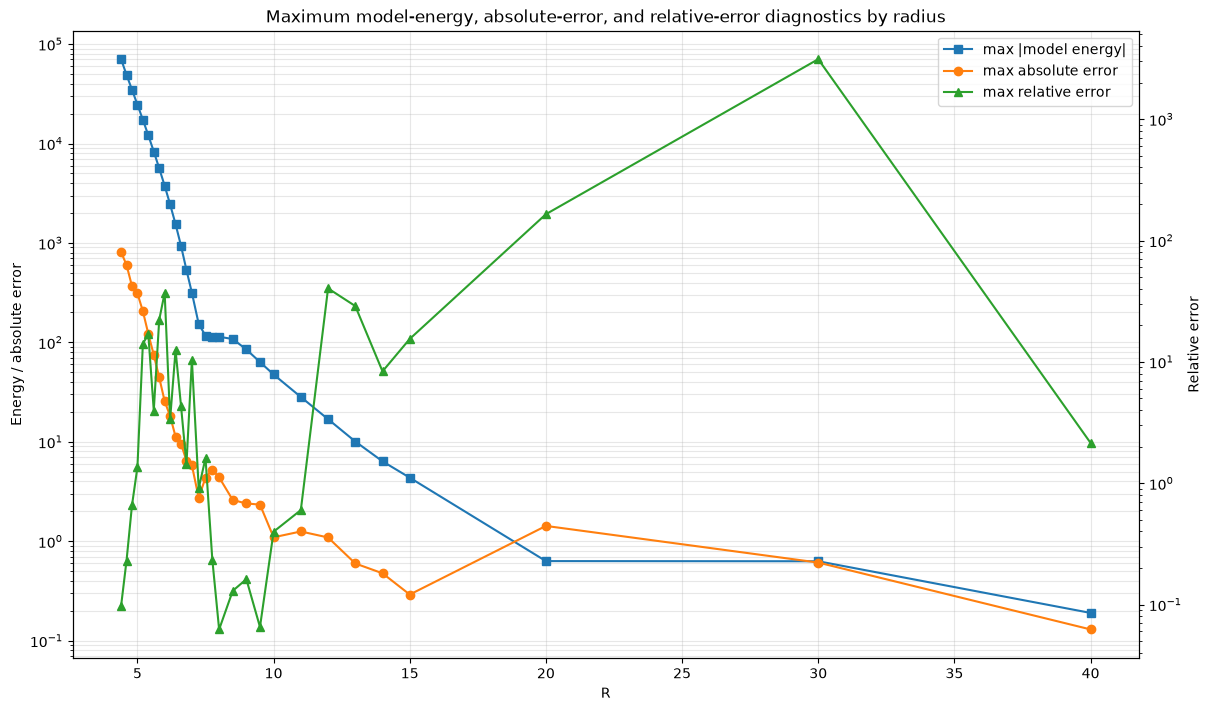

Worst pointwise relative error at each R:
R      theta1   theta2   phi      V_ab_initio      V_fit            abs_error        rel_error
 4.40    77.02   170.28     8.35  2.37431091e+03  2.60571440e+03  2.31403489e+02  9.74613256e-02
 4.60    87.61   104.61    42.10  3.56185622e+02  4.38171777e+02  8.19861550e+01  2.30178171e-01
 4.80    88.16   105.22   164.98  6.91210650e+01  1.14529409e+02  4.54083444e+01  6.56939306e-01
 5.00    91.48   118.49   157.46  2.12255680e+01  4.99940514e+01  2.87684834e+01  1.35536931e+00
 5.20    93.23    65.14   110.49  1.78542200e+00  2.70152867e+01  2.52298647e+01  1.41310372e+01
 5.40    98.77   126.57    20.96 -1.03012100e+00  1.63143886e+01  1.73445096e+01  1.68373517e+01
 5.60    90.80   145.54   137.94 -3.78678400e+00  1.12375547e+01  1.50243387e+01  3.96757213e+00
 5.80   102.93    44.14   144.10  7.54420000e-02  1.75066604e+00  1.67522404e+00  2.22054564e+01
 6.00    77.02   170.28     8.35 -1.47687000e-01 -5.62204222e+00  5.47435522e+00  3.706

In [23]:
# Maximum absolute-error and model-energy diagnostics by radius.
# Run a model-building cell first; this prefers the C2 radial model when available.

max_diagnostic_model_candidates = [
    ("c2_pes_model", "evaluate_c2_pes"),
    ("minimized_truncated_svd_hysteresis_pes_model", "evaluate_minimized_pes"),
    ("minimized_truncated_svd_pes_model", "evaluate_minimized_pes"),
    ("incremental_truncated_svd_pes_model", "evaluate_minimized_pes"),
    ("minimized_pes_model", "evaluate_minimized_pes"),
]
max_available_model_pairs = [
    (model_name, evaluator_name)
    for model_name, evaluator_name in max_diagnostic_model_candidates
    if model_name in globals() and evaluator_name in globals()
]
if not max_available_model_pairs:
    raise NameError(
        "No already-created PES model was found. Run one of the model-building cells before this plotting cell."
    )

max_diagnostic_model_name, max_diagnostic_evaluator_name = max_available_model_pairs[0]
max_diagnostic_model = globals()[max_diagnostic_model_name]
max_diagnostic_evaluator = globals()[max_diagnostic_evaluator_name]
print(f"Using model: {max_diagnostic_model_name}")
print(f"Using evaluator: {max_diagnostic_evaluator_name}")

max_diagnostic_data = all_data if "all_data" in globals() else numpy.loadtxt("data/all_avcbs_uniform.dat")
max_diagnostic_radii = numpy.unique(max_diagnostic_data[:, 0])

max_absolute_error_by_radius = []
max_abs_model_energy_by_radius = []
max_model_energy_by_radius = []
max_relative_error_by_radius = []
max_relative_error_records = []

for r_value in max_diagnostic_radii:
    radius_data = max_diagnostic_data[max_diagnostic_data[:, 0] == r_value]
    reference_energy = radius_data[:, 4]
    fitted_energy = max_diagnostic_evaluator(
        max_diagnostic_model,
        float(r_value),
        radius_data[:, 1],
        radius_data[:, 2],
        radius_data[:, 3],
        angles_in_degrees=True,
    )

    residuals = fitted_energy - reference_energy
    max_absolute_error_by_radius.append(float(numpy.max(numpy.abs(residuals))))
    max_abs_model_energy_by_radius.append(float(numpy.max(numpy.abs(fitted_energy))))
    max_model_energy_by_radius.append(float(numpy.max(fitted_energy)))
    nonzero_reference = numpy.abs(reference_energy) > 0
    relative_error = numpy.full_like(reference_energy, numpy.nan, dtype=float)
    relative_error[nonzero_reference] = (
        numpy.abs(residuals[nonzero_reference]) / numpy.abs(reference_energy[nonzero_reference])
    )
    max_relative_error_by_radius.append(float(numpy.nanmax(relative_error)))

    for point_index in numpy.where(numpy.isfinite(relative_error))[0]:
        max_relative_error_records.append({
            "R": float(r_value),
            "theta1": float(radius_data[point_index, 1]),
            "theta2": float(radius_data[point_index, 2]),
            "phi": float(radius_data[point_index, 3]),
            "reference_energy": float(reference_energy[point_index]),
            "fitted_energy": float(fitted_energy[point_index]),
            "absolute_error": float(abs(residuals[point_index])),
            "relative_error": float(relative_error[point_index]),
        })

max_absolute_error_by_radius = numpy.asarray(max_absolute_error_by_radius)
max_abs_model_energy_by_radius = numpy.asarray(max_abs_model_energy_by_radius)
max_model_energy_by_radius = numpy.asarray(max_model_energy_by_radius)
max_relative_error_by_radius = numpy.asarray(max_relative_error_by_radius)

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
ax.plot(
    max_diagnostic_radii,
    max_abs_model_energy_by_radius,
    marker="s",
    label="max |model energy|",
)
ax.plot(
    max_diagnostic_radii,
    max_absolute_error_by_radius,
    marker="o",
    label="max absolute error",
)

ax2 = ax.twinx()
ax2.plot(
    max_diagnostic_radii,
    max_relative_error_by_radius,
    marker="^",
    color="tab:green",
    label="max relative error",
)

ax.set_xlabel("R")
ax.set_ylabel("Energy / absolute error")
ax2.set_ylabel("Relative error")
ax.set_title("Maximum model-energy, absolute-error, and relative-error diagnostics by radius")
ax.set_yscale("log")
ax2.set_yscale("log")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="best")
ax.grid(True, which="both", alpha=0.3)
plt.show()

max_radius_diagnostic_summary = {
    "model": max_diagnostic_model_name,
    "R": max_diagnostic_radii,
    "max_abs_model_energy": max_abs_model_energy_by_radius,
    "max_model_energy": max_model_energy_by_radius,
    "max_absolute_error": max_absolute_error_by_radius,
    "max_relative_error": max_relative_error_by_radius,
}

max_relative_error_records = sorted(
    max_relative_error_records,
    key=lambda record: record["relative_error"],
    reverse=True,
)

worst_relative_error_point_by_radius = {}
for record in max_relative_error_records:
    r_value = record["R"]
    if r_value not in worst_relative_error_point_by_radius:
        worst_relative_error_point_by_radius[r_value] = record

worst_relative_error_points_by_radius = [
    worst_relative_error_point_by_radius[float(r_value)]
    for r_value in max_diagnostic_radii
    if float(r_value) in worst_relative_error_point_by_radius
]

print("Worst pointwise relative error at each R:")
print(
    "R      theta1   theta2   phi      "
    "V_ab_initio      V_fit            abs_error        rel_error"
)
for record in worst_relative_error_points_by_radius:
    print(
        f"{record['R']:5.2f} "
        f"{record['theta1']:8.2f} "
        f"{record['theta2']:8.2f} "
        f"{record['phi']:8.2f} "
        f"{record['reference_energy']:15.8e} "
        f"{record['fitted_energy']:15.8e} "
        f"{record['absolute_error']:15.8e} "
        f"{record['relative_error']:15.8e}"
    )
